# **FIT5196 Assessment 2, Task 1: Data Cleansing**

---



#### **Group 57:**
Member 1: Stefanus Felix Wigna Sunarto (35556439), ssun0105@student.monash.edu

Member 2: Mutia Salsabila, (34342648), msal0071@student.monash.edu

Member 3: Catharina (35698977), ccat0006@student.monash.edu

Member 4: Mutiara Hernowo (35236043), mher0030@student.monash.edu

Member 5: Ferina Lestari Damamain (35976292), fdam0002@student.monash.edu


---

# **Table of Contents**

### **1. Import Library & Load Dataset**
### **2. Dirty Data**

#### **2.1 Initial Data Overview**

#### 2.2 Model Free Anomaly Detection
- 2.2.1 Date
- 2.2.2 Branch Code
- 2.2.3 Order Type vs Time
- 2.2.4 Menu & Order Items
- 2.2.5 Item Prices & Order Price Validation
- 2.2.6 Customer Coordinates (lat/lon)
#### 2.3 Data Handling (fix detected anomalies)
- 2.3.1 Date Format Errors
- 2.3.2 Branch Code Errors
- 2.3.3 Order Type Mislabels
- 2.3.4 Order Items (Wrong Item)
- 2.3.5 Order Price Errors
- 2.3.6 Coordinate Errors
- 2.3.7 Coordinate Validation Against nodes.csv
#### 2.4 Dijkstra Implementation: Distance Validation
- 2.4.1 Graph Validation on Outlier File
- 2.4.2 Validation on All Detected Error Rows
- 2.4.3 Validate Distance on Remaining Clean Rows
#### 2.5 Fee Model & Loyalty Validation
- 2.5.1 Fee Model Interpretation
- 2.5.2 Loyalty Validation
#### 2.6 Conclusion

### **3. Missing Data**
#### 3.1 Missing Type Check per Variable
#### 3.2 Imputation: Branch Code
#### 3.3 Imputation: distance_to_customer_KM
#### 3.3 Imputation: delivery_fee
#### 3.4 Conclusion

### **4. Outlier Data**
#### 4.1 Exploratory Data Analysis
#### 4.2 Residual Calculation for Each Branch
#### 4.3 Outlier Detection
#### 4.4 Residual Visualisation
#### 4.5 Remove Outliers & Save
#### 4.6 Conclusion

# **1. Import Library & Load Dataset**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import ast
import re
import datetime
from itertools import combinations
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt

# For LR model
from sklearn.linear_model import LinearRegression

# For model evaluation matrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from scipy import stats

# For building graph & calculating Dijkstra's shortest distance
import networkx as nx
from scipy.spatial import KDTree

In [ ]:
dirty_data_df = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/student_data/Group057_dirty_data.csv")
missing_data_df = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/student_data/Group057_missing_data.csv")
outlier_data_df = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/student_data/Group057_outlier_data.csv")

branches = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/branches.csv")
edges = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/edges.csv")
nodes = pd.read_csv("/content/drive/Shareddrives/FIT5196_S1_2026/Assessment2/data/nodes.csv")

# **2. Dirty Data**

This section documents the process of finding and fixing anomalies in `Group057_dirty_data.csv`
to produce `Group057_dirty_data_solution.csv`.

Per the spec, the following columns are **error-free** and are not checked:
- `order_id`
- `time`
- numeric quantity in `order_items`
- `delivery_fee`

Every other column is subject to anomaly detection and correction.

**Approach — two phases:**

**Phase 1 — Model-free detection**
Columns that can be validated through data rules, reference files, or menu/price logic alone:
`date`, `branch_code`, `order_type`, `order_items`, `order_price`, `customer_lat`, `customer_lon`

**Phase 2 — Model-based validation**
Columns that require a graph or regression model to validate:
- `distance_to_customer_KM` — validated via Dijkstra shortest path on the road network graph
- `customerHasloyalty?` — validated via a per-branch LinearRegression fee model,
  using `delivery_fee` (error-free) as ground truth

## **2.1 Initial Data Overview**

In [ ]:
dirty_data_df.head()

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee
0,ORDK10905,2018-03-23,10:42:15,Breakfast,BK,"[('Pancake', 10), ('Cereal', 3)]",305.5,-37.818794,144.916853,0,11.980,16.964376
1,ORDY09322,2018-11-25,18:49:00,Dinner,bk,"[('Salmon', 2), ('Shrimp', 5), ('Pasta', 1), (...",694.5,-37.824029,144.956985,0,8.406,14.285419
2,ORDZ06446,2018-06-01,12:54:05,Lunch,NS,"[('Steak', 7), ('Burger', 2), ('Chicken', 2), ...",470.2,-37.801560,145.007107,0,9.620,14.725456
3,ORDY09022,2018-05-19,12:33:48,Lunch,TP,"[('Chicken', 4), ('Fries', 3), ('Salad', 7), (...",757.4,-37.803438,144.962735,0,9.402,14.056128
4,ORDZ07669,2018-07-18,14:35:29,Lunch,NS,"[('Chicken', 9), ('Fries', 2), ('Salad', 7), (...",567.4,-37.810938,144.968176,0,7.378,12.741040


In [ ]:
dirty_data_df.shape

(500, 12)

In [ ]:
dirty_data_df.dtypes

,0
order_id,object
date,object
time,object
order_type,object
branch_code,object
order_items,object
order_price,float64
customer_lat,float64
customer_lon,float64
customerHasloyalty?,int64


In [ ]:
dirty_data_df.isna().sum()

,0
order_id,0
date,0
time,0
order_type,0
branch_code,0
order_items,0
order_price,0
customer_lat,0
customer_lon,0
customerHasloyalty?,0


In [ ]:
# Numeric summary to flag anything obviously out of range
dirty_data_df.describe()

,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,491.248500,-30.753410,143.505487,0.126000,8.672232,13.661620
std,274.225556,25.336922,16.298897,0.332182,1.708830,2.511295
min,54.250000,-37.833482,-37.811969,0.000000,3.594000,5.164781
25%,277.500000,-37.817439,144.951543,0.000000,7.701750,12.404152
50%,441.600000,-37.811563,144.964606,0.000000,8.634500,13.723029
75%,661.150000,-37.803700,144.982606,0.000000,9.826750,15.249526
max,1395.000000,144.975712,145.020570,1.000000,13.735000,20.573464


In [ ]:
# Categorial summary
dirty_data_df.describe(include="object")

,order_id,date,time,order_type,branch_code,order_items
count,500,500,500,500,500,500
unique,500,294,72,3,6,495
top,ORDZ07224,2018-11-15,11:32:57,Breakfast,NS,"[('Coffee', 7), ('Pancake', 3)]"
freq,1,7,19,173,168,2


**Observations:**
- No null values.
- There are 6 unique values in `branch_code` while there are only 3 branch in branch dataset
- `customer_lat` max ≈ **144.97** and mean ≈ **-30.7** (expected ≈ -37.8), coordinate errors already visible.

These will be investigated more next.


**Overlap Check Helper**

The spec guarantees **at most one anomaly per row**. We define `check_overlaps` early
and call it after adding each new error type to verify this holds throughout detection.

In [ ]:
def check_overlaps(error_indexes):
    """Print pairwise overlap counts between all error index lists."""
    for a, b in combinations(error_indexes.keys(), 2):
        overlap = set(error_indexes[a]) & set(error_indexes[b])
        print(f"{a} vs {b}: {len(overlap)} overlap")
        if overlap:
            print("  overlapping indices:", sorted(overlap)[:20])

# Initialise the error index dictionary to store error detected
error_indexes = {}

## **2.2 Model  Free Anomaly Detection**

### **2.2.1 Date**

**Justification:** The spec requires `date` in `YYYY-MM-DD` format. We check the
outlier file first to confirm the expected format, then detect deviations in the dirty data.

We use `pd.to_datetime` with `errors='coerce'` to flag rows that fail strict `YYYY-MM-DD`
parsing. Visual inspection of the failures reveals **two sub-types**:
- **Type 1 (`DD-MM-YYYY`)**: day and year are transposed (e.g. `03-03-2018`)
- **Type 2 (`YYYY-DD-MM`)**: month and day are swapped within the YYYY prefix (e.g. `2018-14-03`,
  where 14 cannot be a month so the parser rejects it)

In [ ]:
# Confirm correct format in the outlier file
outlier_data_df["date"].head()

,date
0,2018-08-15
1,2018-02-04
2,2018-01-14
3,2018-06-19
4,2018-04-04


In [ ]:
# Flag rows that fail strict YYYY-MM-DD parsing
temp_dates = pd.to_datetime(dirty_data_df["date"], format="%Y-%m-%d", errors="coerce")
print("Rows that failed to parse:", temp_dates.isna().sum())
print()
dirty_data_df[temp_dates.isna()][["date"]]

Rows that failed to parse: 37



,date
6,2018-14-03
13,03-03-2018
32,2018-21-04
52,2018-28-12
85,2018-27-07
98,2018-30-07
100,2018-28-04
147,2018-16-12
150,2018-24-05
168,2018-27-12


In [ ]:
# Separate the two sub-types for clarity
type1_mask = temp_dates.isna() & dirty_data_df["date"].str.match(r"^\d{2}-\d{2}-\d{4}$")  # DD-MM-YYYY
type2_mask = temp_dates.isna() & dirty_data_df["date"].str.match(r"^\d{4}-\d{2}-\d{2}$")  # YYYY-DD-MM

print(f"Type 1 (DD-MM-YYYY) : {type1_mask.sum()} rows (e.g. {dirty_data_df[type1_mask]["date"].iloc[0]})")
print(f"Type 2 (YYYY-DD-MM) : {type2_mask.sum()} rows (e.g. {dirty_data_df[type2_mask]["date"].iloc[0]})")

Type 1 (DD-MM-YYYY) : 15 rows (e.g. 03-03-2018)
Type 2 (YYYY-DD-MM) : 22 rows (e.g. 2018-14-03)


In [ ]:
date_error = dirty_data_df[temp_dates.isna()].index.tolist()
error_indexes["date_error"] = date_error
print("Total date_error:", len(date_error))

Total date_error: 37


**Observation:** A total of 37 date errors were identified, consisting of **syntactical anomalies (wrong format)** including 15 entries in DD-MM-YYYY format and 22 entries in YYYY-DD-MM format, both of which deviate from the expected YYYY-MM-DD format.

### **2.2.2 Branch Code**

**Justification:** `branches.csv` is the authoritative reference for valid branch codes.
All codes there are uppercase (`NS`, `TP`, `BK`). Any value not in that set is an error.
Value counts show lowercase variants (`bk`, `ns`, `tp`) exist in the dirty data.

In [ ]:
dirty_data_df.branch_code.value_counts()

,count
branch_code,
NS,168
BK,155
TP,152
tp,11
bk,7
ns,7


In [ ]:
branches.head()

,branch_code,branch_name,branch_lat,branch_lon
0,NS,Nickolson,-37.773803,144.983647
1,TP,Thompson,-37.861835,144.905716
2,BK,Bakers,-37.815834,145.046450


In [ ]:
valid_branch_codes = set(branches["branch_code"])

branch_code_error = dirty_data_df.index[~dirty_data_df["branch_code"].isin(valid_branch_codes)].tolist()

error_indexes["branch_code_error"] = branch_code_error
print("Total branch_code_error:", len(branch_code_error))

Total branch_code_error: 25


**Finding:** In `branch_code`, we found that 25 rows error with lowercase branch codes (e.g. tp, bk, ns) instead of the required uppercase format (TP, BK, NS), which classified as **syntactical anomalies**.

In [ ]:
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap


### **2.2.3 Order Type vs Time**

**Justification:** The specification defines three fixed, non-overlapping meal time windows,
and `time` is explicitly listed as error-free. This makes the time-derived
meal type the ground truth. Any disagreement with the recorded `order_type` is a mislabel.

- Breakfast: 08:00:00 - 12:00:00
- Lunch:     12:00:01 – 16:00:00
- Dinner:    16:00:01 – 20:00:00

In [ ]:
dirty_data_df.order_type.value_counts()

,count
order_type,
Breakfast,173
Lunch,169
Dinner,158


In [ ]:
# Create function to derived expected meal time based on time data
def expected_meal_from_time(t):
    """Derive expected meal type from time string (HH:MM:SS)."""
    h, m, s = map(int, t.split(":"))
    seconds = h * 3600 + m * 60 + s

    if 8 * 3600 <= seconds <= 12 * 3600:
        return "Breakfast"
    elif 12 * 3600 + 1 <= seconds <= 16 * 3600:
        return "Lunch"
    elif 16 * 3600 + 1 <= seconds <= 20 * 3600:
        return "Dinner"
    else:
        return "Outside meal time"

expected_order_type = dirty_data_df["time"].apply(expected_meal_from_time)
print("Expected meal type distribution:")
print(expected_order_type.value_counts())

Expected meal type distribution:
time
Breakfast    182
Lunch        165
Dinner       153
Name: count, dtype: int64


In [ ]:
# Check mismatch data
order_type_error = dirty_data_df[expected_order_type != dirty_data_df["order_type"]].index.tolist()

error_indexes["order_type_error"] = order_type_error
print("Total order_type mismatches:", len(order_type_error))

Total order_type mismatches: 37


**Finding:**
37 rows had an order_type that didn't match their actual order time (**syntactical anomalies**), for example, a row placed at dinner time was incorrectly labeled as "Lunch".

In [ ]:
dirty_data_df.loc[order_type_error]

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee
10,ORDY01745,2018-11-03,18:08:27,Lunch,TP,"[('Pasta', 9), ('Shrimp', 7), ('Salmon', 4), (...",894.50,-37.806190,144.978321,0,9.635,15.173062
15,ORDC01870,2018-08-05,15:05:54,Dinner,NS,"[('Fries', 7), ('Steak', 5), ('Burger', 1)]",340.00,-37.812249,144.988491,0,8.684,16.149853
18,ORDK10638,2018-04-06,11:02:32,Lunch,BK,"[('Eggs', 2), ('Pancake', 7), ('Coffee', 9), (...",344.25,-37.811788,144.984438,0,5.685,10.601610
24,ORDI04726,2018-03-07,10:01:41,Lunch,NS,"[('Cereal', 6), ('Coffee', 8), ('Eggs', 1), ('...",402.00,-37.819160,144.984774,0,9.005,14.149704
54,ORDA00085,2018-04-10,11:12:40,Lunch,BK,"[('Eggs', 8), ('Cereal', 4), ('Pancake', 9), (...",538.25,-37.820609,144.966868,0,7.882,12.681673
72,ORDB11059,2018-11-07,18:18:35,Lunch,TP,"[('Pasta', 4), ('Shrimp', 5), ('Salmon', 4), (...",894.00,-37.811324,144.961904,0,8.362,13.227868
102,ORDK08583,2018-02-07,09:10:59,Dinner,BK,"[('Pancake', 2), ('Coffee', 2)]",63.50,-37.805073,144.927725,0,10.764,16.221044
112,ORDC06864,2018-04-01,10:52:23,Lunch,NS,"[('Coffee', 5), ('Eggs', 5)]",147.50,-37.819040,144.954318,0,9.174,16.608473
126,ORDC06814,2018-11-12,18:28:43,Breakfast,NS,"[('Shrimp', 4), ('Pasta', 9), ('Salmon', 5), (...",878.50,-37.815646,144.938578,0,10.002,16.098799
128,ORDJ04133,2018-01-04,08:00:00,Lunch,TP,"[('Eggs', 5), ('Pancake', 5)]",231.25,-37.821023,144.947451,1,8.981,5.256999


In [ ]:
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap


### **2.2.4 Menu & Order Items**

**Justification:** The specification states each meal type has an exclusive set of items, for example
Breakfast items cannot appear in Lunch or Dinner orders, and vice versa.

To infer the true menu reliably, we use the **outlier file** as a clean reference
(spec guarantees no anomalies other than outliers in `delivery_fee`). We also cross-check
with the clean rows from the dirty file to confirm consistency.

Then, we flag dirty rows where an item does not belong to the recorded `order_type` menu,
excluding rows already detected as `order_type_error` (since their label is wrong, not their items).

In [ ]:
# Create a function to create a menu set
def get_menu_set(df):
    """Build a dictionary of meal -> sorted list of items from a dataframe."""
    menu_by_meal = {}
    for meal in sorted(df["order_type"].unique()):
        items = set()
        for order_items in df[df["order_type"] == meal]["order_items_parsed"]:
            for item, qty in order_items:
                items.add(item)
        menu_by_meal[meal] = sorted(items)
    return menu_by_meal

In [ ]:
# Parse order_items string to list of tuples
dirty_data_df["order_items"] = dirty_data_df["order_items"].apply(ast.literal_eval)

outlier_copy_df = outlier_data_df.copy()
outlier_copy_df["order_items_parsed"] = outlier_copy_df["order_items"].apply(ast.literal_eval)

# Since each row has only one anomaly, rows with date/branch errors are guaranteed to have correct menu and order_type data, so we use them as reference
trusted_index = sorted(set(date_error + branch_code_error))
trusted_rows = dirty_data_df.loc[trusted_index].copy()
trusted_rows["order_items_parsed"] = trusted_rows["order_items"]

print(f"Trusted rows (known date/branch errors): {len(trusted_rows)}")
print(f"Total rows in outlier data: {len(outlier_copy_df)}")

Trusted rows (known date/branch errors): 62
Total rows in outlier data: 500


**Finding:** To correctly identify which menu items belong to each meal type, 62 rows with known date/branch errors were used as a trusted reference, since those rows are guaranteed to have valid order type and menu data.

In [ ]:
menu_from_trusted = get_menu_set(trusted_rows)
menu_from_outlier = get_menu_set(outlier_copy_df)

# Compare both dataset (should be identical if trusted rows are clean)
for meal in sorted(set(menu_from_trusted) | set(menu_from_outlier)):
    ts = set(menu_from_trusted.get(meal, []))
    os = set(menu_from_outlier.get(meal, []))
    print(f"{meal}")
    print(f"  Trusted : {sorted(ts)}")
    print(f"  Outlier : {sorted(os)}")
    print(f"  Match   : {ts == os}")
    print(f"  Only in trusted: {sorted(ts - os)}")
    print(f"  Only in outlier: {sorted(os - ts)}")
    print()

Breakfast
  Trusted : ['Cereal', 'Coffee', 'Eggs', 'Pancake']
  Outlier : ['Cereal', 'Coffee', 'Eggs', 'Pancake']
  Match   : True
  Only in trusted: []
  Only in outlier: []

Dinner
  Trusted : ['Fish&Chips', 'Pasta', 'Salmon', 'Shrimp']
  Outlier : ['Fish&Chips', 'Pasta', 'Salmon', 'Shrimp']
  Match   : True
  Only in trusted: []
  Only in outlier: []

Lunch
  Trusted : ['Burger', 'Chicken', 'Fries', 'Salad', 'Steak']
  Outlier : ['Burger', 'Chicken', 'Fries', 'Salad', 'Steak']
  Match   : True
  Only in trusted: []
  Only in outlier: []



**Finding:** Both sources produce the same menu sets, so the menus are exclusive
and the clean reference is reliable. We use `menu_from_outlier` as the authoritative menu
since it is guaranteed clean by the spec.

In [ ]:
menu_by_meal = {meal: set(items) for meal, items in menu_from_outlier.items()}

def items_match_meal(order_items, meal):
    """Return True if all items in the order belong to the given meal's menu."""
    valid_items = menu_by_meal.get(meal, set())
    return all(item in valid_items for item, qty in order_items)

# Only check rows not already flagged as order_type_error
not_order_type_error = ~dirty_data_df.index.isin(order_type_error)

items_match_recorded_order_type = pd.Series([items_match_meal(items, meal) for items, meal in zip(dirty_data_df["order_items"], dirty_data_df["order_type"])],
                                            index=dirty_data_df.index)

order_items_error = dirty_data_df[not_order_type_error & (~items_match_recorded_order_type)].index.tolist()

error_indexes["order_items_error"] = order_items_error
print("order_items_error:", len(order_items_error))
dirty_data_df.loc[order_items_error, ["order_type", "order_items"]]

order_items_error: 37


,order_type,order_items
4,Lunch,"[(Chicken, 9), (Fries, 2), (Salad, 7), (Fish&C..."
19,Lunch,"[(Chicken, 10), (Pancake, 5), (Steak, 5), (Sal..."
33,Breakfast,"[(Pancake, 2), (Cereal, 5), (Burger, 5), (Coff..."
37,Lunch,"[(Pasta, 7), (Chicken, 5), (Burger, 8), (Fries..."
59,Lunch,"[(Steak, 9), (Shrimp, 1)]"
68,Breakfast,"[(Cereal, 10), (Coffee, 7), (Eggs, 3), (Fries,..."
75,Lunch,"[(Eggs, 2), (Chicken, 3), (Fries, 9), (Burger,..."
77,Dinner,"[(Eggs, 1), (Salmon, 8), (Fish&Chips, 2)]"
81,Breakfast,"[(Steak, 6), (Pancake, 9)]"
86,Dinner,"[(Shrimp, 4), (Cereal, 1)]"


In [ ]:
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
date_error vs order_items_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap
branch_code_error vs order_items_error: 0 overlap
order_type_error vs order_items_error: 0 overlap


### **2.2.5 Item Prices & Order Price Validation**

**Justification:** `order_price` is not listed as error-free in the spec. To validate it,
we need the unit price of every menu item.

We solve for prices using `numpy.linalg.lstsq` on the clean outlier file. Each order gives
one linear equation: `Σ (qty_i × price_i) = order_price`. With many rows the system is
overdetermined; lstsq finds the best-fit solution. A max residual of 0.0 confirms the prices
are exact.

We solve per meal type separately to keep each sub-system well-conditioned, then verify
the solved prices reproduce all outlier file prices exactly before using them on dirty data.

In [ ]:
# Price per item
def solve_item_prices(df, meal, menu_items):
    """Solve for item unit prices using least squares on clean rows."""
    meal_df = df[df["order_type"] == meal].copy()
    menu_items = sorted(menu_items)

    X, y = [], []
    for _, row in meal_df.iterrows():
        qty_dict = {item: 0 for item in menu_items}
        for item, qty in row["order_items_parsed"]:
            if item in qty_dict:
                qty_dict[item] += qty
        X.append([qty_dict[item] for item in menu_items])
        y.append(row["order_price"])

    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    prices, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    max_residual = np.max(np.abs(X @ prices - y))

    result = pd.DataFrame({
        "meal": meal,
        "item": menu_items,
        "estimated_price": prices.round(4)
    })
    print(f"  {meal}: rank={np.linalg.matrix_rank(X)}, max_residual={max_residual:.8f}")
    return result

In [ ]:
# Solve from outlier file (guaranteed clean)
print("Solving prices from outlier file:")
price_results = []
for meal, items in menu_from_outlier.items():
    price_results.append(solve_item_prices(outlier_copy_df, meal, items))

item_prices = pd.concat(price_results, ignore_index=True)
item_prices

Solving prices from outlier file:
  Breakfast: rank=4, max_residual=0.00000000
  Dinner: rank=4, max_residual=0.00000000
  Lunch: rank=5, max_residual=0.00000000


,meal,item,estimated_price
0,Breakfast,Cereal,21.00
1,Breakfast,Coffee,7.50
2,Breakfast,Eggs,22.00
3,Breakfast,Pancake,24.25
4,Dinner,Fish&Chips,35.00
5,Dinner,Pasta,27.50
6,Dinner,Salmon,41.00
7,Dinner,Shrimp,54.00
8,Lunch,Burger,31.00
9,Lunch,Chicken,32.00


In [ ]:
# Cross-check: also solve from trusted dirty rows (should match)
print("Solving prices from trusted dirty rows:")
price_results_d = []
trusted_rows["order_items_parsed"] = trusted_rows["order_items"]
for meal, items in menu_from_outlier.items():
    price_results_d.append(solve_item_prices(trusted_rows, meal, items))

item_prices_d = pd.concat(price_results_d, ignore_index=True)
print()
print("Prices match between outlier and trusted dirty rows?")
item_prices_d[["meal","item","estimated_price"]].equals(item_prices[["meal","item","estimated_price"]])

Solving prices from trusted dirty rows:
  Breakfast: rank=4, max_residual=0.00000000
  Dinner: rank=4, max_residual=0.00000000
  Lunch: rank=5, max_residual=0.00000000

Prices match between outlier and trusted dirty rows?


True

In [ ]:
# Build price lookup map and calculator
price_map = dict(zip(item_prices["item"], item_prices["estimated_price"]))

# Calculate order price using item quantities and price per item
def calculate_order_price(order_items):
    """Calculate expected order price from item quantities and solved prices."""
    return sum(price_map[item] * qty for item, qty in order_items)

In [ ]:
# Verify on trusted rows (the price diff should be 0 for all)
trusted_rows["calculated_order_price"] = trusted_rows["order_items"].apply(calculate_order_price)
trusted_rows["price_diff"] = (trusted_rows["order_price"] - trusted_rows["calculated_order_price"]).round(2)

print("Price diff on trusted rows (should all be 0):")
trusted_rows["price_diff"].describe()

Price diff on trusted rows (should all be 0):


,price_diff
count,62.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


**Finding:** The calculated order price perfectly matched the recorded price across all 62 trusted rows (difference = 0 for all), so that the price calculation logic is correct and can be reliably used to detect price errors in the rest of the data.

In [ ]:
# Now detect order_price errors in remaining undetected rows in dirty data
already_detected = set().union(*error_indexes.values())
price_check_df = dirty_data_df[~dirty_data_df.index.isin(already_detected)].copy()

calculated_prices = price_check_df["order_items"].apply(calculate_order_price)
price_diff = price_check_df["order_price"] - calculated_prices

order_price_error = price_check_df[price_diff.round(2) != 0].index.tolist()

error_indexes["order_price_error"] = order_price_error
print("order_price_error:", len(order_price_error))

order_price_error: 37


**Finding:** 37 rows in dirty data had an order_price that didn't match the expected total calculated from the items ordered and their prices.

In [ ]:
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
date_error vs order_items_error: 0 overlap
date_error vs order_price_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap
branch_code_error vs order_items_error: 0 overlap
branch_code_error vs order_price_error: 0 overlap
order_type_error vs order_items_error: 0 overlap
order_type_error vs order_price_error: 0 overlap
order_items_error vs order_price_error: 0 overlap


### **2.2.6 Customer Coordinates (lat/lon)**

**Justification:** The specification states the restaurant serves **Melbourne customers only**.
We use the **Melbourne Metropolitan Area bounding box** from Wikipedia
([Module:Location map/data/Australia Victoria Melbourne metropolitan area complete](https://en.wikipedia.org/wiki/Module:Location_map/data/Australia_Victoria_Melbourne_metropolitan_area_complete))
as the geographic reference for valid coordinates:

| | Value |
|---|---|
| North (lat max) | -37.38 |
| South (lat min) | -38.51 |
| West  (lon min) | 144.4  |
| East  (lon max) | 146.3  |

Since Melbourne is in the **Southern Hemisphere**, all valid latitudes must be **negative**.
Any positive latitude is immediately wrong. We check `customer_lat` and `customer_lon`
on rows not yet flagged for any other error.

We start with numeric stats, then plot the raw coordinates on an interactive map
to visually identify anything outside this bounding box.

In [ ]:
# Check error lon/lat in dirty data
def get_already_detected(error_indexes):
    return set().union(*error_indexes.values())

already_detected = get_already_detected(error_indexes)

error_latlon_df = dirty_data_df[~dirty_data_df.index.isin(already_detected)].copy()

print(f"Rows to check for lat/lon errors: {len(error_latlon_df)}")

Rows to check for lat/lon errors: 327


In [ ]:
# Numeric stats first: flag anything outside Melbourne range
# Melbourne: lat -38.5 to -37.3 (always negative), lon 144.4 to 145.7
print("customer_lat stats:")
print(error_latlon_df["customer_lat"].describe())
print()
print("customer_lon stats:")
print(error_latlon_df["customer_lon"].describe())
print()
print("Rows with lat >= 0 (must be 0 for Melbourne):", (error_latlon_df["customer_lat"] >= 0).sum())

customer_lat stats:
count    327.000000
mean     -27.019231
std       30.695389
min      -37.833482
25%      -37.817529
50%      -37.811032
75%      -37.802837
max      144.975712
Name: customer_lat, dtype: float64

customer_lon stats:
count    327.000000
mean     142.731618
std       20.121967
min      -37.811969
25%      144.950145
50%      144.964064
75%      144.982480
max      145.015699
Name: customer_lon, dtype: float64

Rows with lat >= 0 (must be 0 for Melbourne): 41


**Observations from stats:**
- `customer_lat` max ≈ **144.97** — far outside valid latitude range (-90 to +90).
- Some rows have `lat >= 0`, however, Melbourne is in the Southern Hemisphere, so **all latitudes must be negative**. There are 41 rows with lat > 0 (positive), so it is indicated as error.

We now plot all remaining rows on an interactive map with Melbourne's bounding box to see the full picture.

In [ ]:
# Plot 1: all raw coordinates, same colour, no assumptions
MELB_SW = [-38.5, 144.4]
MELB_NE = [-37.3, 145.7]

m1 = folium.Map(location=[-37.8, 144.96], zoom_start=2, tiles="CartoDB positron")

# Melbourne bounding box
folium.Rectangle(
    bounds=[MELB_SW, MELB_NE],
    color="black", weight=2,
    fill=True, fill_color="lightgreen", fill_opacity=0.08,
    tooltip="Melbourne metro bounding box"
).add_to(m1)

# All points: same colour, no categorisation
customer_cluster = MarkerCluster(name=f"Customer points ({len(error_latlon_df)} orders)").add_to(m1)

for _, row in error_latlon_df.iterrows():
    folium.CircleMarker(
        location=[row["customer_lat"], row["customer_lon"]],
        radius=4,
        color="steelblue", fill=True, fill_color="steelblue", fill_opacity=0.6,
        tooltip=f"{row['order_id']} | lat={row['customer_lat']:.4f}, lon={row['customer_lon']:.4f}"
    ).add_to(customer_cluster)

# Branch markers
for _, b in branches.iterrows():
    folium.Marker(
        location=[b["branch_lat"], b["branch_lon"]],
        tooltip=f"Branch: {b['branch_name']} ({b['branch_code']})",
        icon=folium.Icon(color="green", icon="home")
    ).add_to(m1)

folium.LayerControl().add_to(m1)
display(m1)

**What we see in Plot 1** (zoom out to see all clusters):

Three distinct groups are visible and from closer inspection by interacting with the map since we get to know the lat long on hover:
1. **Main cluster inside the Melbourne box**: valid orders.
2. **Small cluster above the equator** (lat ≈ +37.8, lon ≈ 144–145): correct longitude range
   but positive latitude. Melbourne is Southern Hemisphere so these should be negative →
   **missing minus sign (Type B)**.
3. **Tiny cluster at lat ≈ +144, lon ≈ -37.8**: a lat of ~144 is outside any valid latitude
   range (-90 to +90). Recognising ~144 as a Melbourne *longitude* and ~-37.8 as a Melbourne
   *latitude*, these rows have their columns **swapped (Type A)**.

In [ ]:
# Formalise the two observations into detection masks
# type A: lat > 100 -> value is actually a longitude -> columns are swapped
mask_swap   = error_latlon_df["customer_lat"] > 100
lat_lon_swap_error = error_latlon_df.index[mask_swap].tolist()

# type B: 0 < lat < 100 -> correct magnitude but missing Southern Hemisphere minus sign
mask_poslat = (error_latlon_df["customer_lat"] > 0) & (error_latlon_df["customer_lat"] < 100)
lat_positive_error = error_latlon_df.index[mask_poslat].tolist()

print(f"Type A — swapped lat/lon (lat > 100) : {len(lat_lon_swap_error)} rows")
print(error_latlon_df.loc[lat_lon_swap_error, ["order_id","customer_lat","customer_lon"]].to_string())
print()
print(f"Type B — missing minus sign (0 < lat < 100) : {len(lat_positive_error)} rows")
error_latlon_df.loc[lat_positive_error, ["order_id","customer_lat","customer_lon"]]

Type A — swapped lat/lon (lat > 100) : 4 rows
      order_id  customer_lat  customer_lon
113  ORDA07986    144.975712    -37.809618
222  ORDX08615    144.963765    -37.811969
334  ORDK06373    144.973172    -37.811448
485  ORDI03477    144.957332    -37.805361

Type B — missing minus sign (0 < lat < 100) : 37 rows


,order_id,customer_lat,customer_lon
8,ORDJ03864,37.823406,144.937847
30,ORDC07278,37.823395,145.012280
38,ORDZ03288,37.819153,144.965510
69,ORDI02849,37.818925,144.966116
104,ORDC01510,37.819880,144.943804
110,ORDC07746,37.810949,144.938987
123,ORDZ07001,37.820633,144.966853
124,ORDC07980,37.799332,144.960555
149,ORDB07826,37.804592,144.966955
187,ORDA08600,37.802726,145.005203


In [ ]:
error_indexes["lat_lon_swap_error"]   = lat_lon_swap_error
error_indexes["lat_positive_error"] = lat_positive_error

print("lat_lon_swap_error :", len(lat_lon_swap_error))
print("lat_positive_error :", len(lat_positive_error))

lat_lon_swap_error : 4
lat_positive_error : 37


**Findings:** Two types of location errors were found. There are 4 rows had their latitude and longitude columns swapped and 37 rows were missing a negative sign on the latitude, both causing the customer's location to appear outside Melbourne.

**Final Overlap Check & Error Summary**

**Justification:** We run `check_overlaps` one final time across all 7 error types.
Zero overlaps confirms our detection logic is consistent with the specification which one anomaly for each row.

In [ ]:
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
date_error vs order_items_error: 0 overlap
date_error vs order_price_error: 0 overlap
date_error vs lat_lon_swap_error: 0 overlap
date_error vs lat_positive_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap
branch_code_error vs order_items_error: 0 overlap
branch_code_error vs order_price_error: 0 overlap
branch_code_error vs lat_lon_swap_error: 0 overlap
branch_code_error vs lat_positive_error: 0 overlap
order_type_error vs order_items_error: 0 overlap
order_type_error vs order_price_error: 0 overlap
order_type_error vs lat_lon_swap_error: 0 overlap
order_type_error vs lat_positive_error: 0 overlap
order_items_error vs order_price_error: 0 overlap
order_items_error vs lat_lon_swap_error: 0 overlap
order_items_error vs lat_positive_error: 0 overlap
order_price_error vs lat_lon_swap_error: 0 overlap
order_price_error vs lat_positive_error: 0 overlap
lat_lon_swap_error vs lat_positive_err

In [ ]:
# Summary table
all_error_idx = set().union(*error_indexes.values())

print("=" * 52)
print("COMPLETE ERROR SUMMARY")
print("=" * 52)
for name, idx_list in error_indexes.items():
    print(f"{name:<25}: {len(idx_list):>3} rows")
print("-" * 52)
print(f"{'TOTAL ERRORS':<25}: {len(all_error_idx):>3} rows")
print(f"{'CLEAN ROWS'  :<25}: {500 - len(all_error_idx):>3} rows")

COMPLETE ERROR SUMMARY
date_error               :  37 rows
branch_code_error        :  25 rows
order_type_error         :  37 rows
order_items_error        :  37 rows
order_price_error        :  37 rows
lat_lon_swap_error       :   4 rows
lat_positive_error       :  37 rows
----------------------------------------------------
TOTAL ERRORS             : 214 rows
CLEAN ROWS               : 286 rows


**Finding:** Across the 500 rows, 214 errors were detected spanning 7 different error types, leaving 286 clean rows.

In [ ]:
# Check index for each error
for name, idx_list in error_indexes.items():
    print(f"{name} = {sorted(idx_list)}")
    print()

date_error = [6, 13, 32, 52, 85, 98, 100, 147, 150, 168, 192, 194, 201, 202, 243, 245, 261, 267, 269, 301, 303, 306, 314, 324, 394, 400, 402, 412, 420, 424, 425, 426, 436, 437, 457, 473, 491]

branch_code_error = [1, 22, 42, 87, 118, 138, 141, 143, 167, 189, 212, 240, 248, 249, 289, 292, 293, 295, 298, 375, 377, 403, 410, 439, 446]

order_type_error = [10, 15, 18, 24, 54, 72, 102, 112, 126, 128, 136, 137, 140, 148, 159, 170, 214, 228, 256, 271, 279, 304, 309, 311, 313, 317, 323, 346, 354, 363, 365, 371, 414, 423, 465, 466, 496]

order_items_error = [4, 19, 33, 37, 59, 68, 75, 77, 81, 86, 89, 93, 121, 146, 152, 162, 200, 204, 205, 208, 209, 225, 229, 276, 278, 294, 299, 322, 361, 367, 372, 382, 385, 415, 463, 468, 475]

order_price_error = [12, 50, 53, 62, 63, 79, 101, 134, 142, 145, 178, 185, 190, 210, 221, 223, 227, 241, 265, 274, 320, 321, 326, 333, 337, 339, 350, 360, 366, 391, 392, 427, 445, 455, 474, 486, 492]

lat_lon_swap_error = [113, 222, 334, 485]

lat_positive_error = [8, 30

**Conclusion**

EDA identified **7 distinct error types** across the dirty dataset:

| # | Error Type | Column(s) | Count | Fix |
|---|---|---|---|---|
| 1 | Wrong date format | `date` | 37 | Reparse (Type1: `dayfirst=True`, Type2: swap MM-DD) |
| 2 | Lowercase branch code | `branch_code` | 25 | `.str.upper()` |
| 3 | `order_type` mislabelled | `order_type` | 37 | Derive from `time` window |
| 4 | Item from wrong meal | `order_items` | 37 | Replace wrong item with correct meal item |
| 5 | `order_price` wrong | `order_price` | 37 | Recalculate from verified item prices |
| 6 | Lat/lon fully swapped | `customer_lat`, `customer_lon` | 4 | Swap columns + recalculate distance |
| 7 | Lat missing minus sign | `customer_lat` | 37 | Negate lat + recalculate distance |

All error index sets are **fully disjoint** — consistent with spec.

**Verified item prices** (max residual = 0.0 from clean outlier file):

| Breakfast | | Lunch | | Dinner | |
|---|---|---|---|---|---|
| Cereal | 21.00 | Burger | 31.00 | Fish&Chips | 35.00 |
| Coffee | 7.50 | Chicken | 32.00 | Pasta | 27.50 |
| Eggs | 22.00 | Fries | 12.00 | Salmon | 41.00 |
| Pancake | 24.25 | Salad | 17.20 | Shrimp | 54.00 |
| | | Steak | 45.00 | | |

**Next step:** Data handling and output `Group057_dirty_data_solution.csv`.

## **2.3 Data Handling (fix detected anomalies)**

We apply all fixes to a copy of the dirty dataframe (`cleaned_df`), leaving the original
untouched for reference. Fixes are applied in error-type order, each verified immediately after.

In [ ]:
# Start from a clean copy
cleaned_df = dirty_data_df.copy()

### **2.3.1 Date Format Errors**

Two sub-types detected:
- **Type 1 (`DD-MM-YYYY`**): reparse with `dayfirst=True`
- **Type 2 (`YYYY-DD-MM`**): swap the month and day components

In [ ]:
def fix_date(date_str):
    """Fix both date format error sub-types to YYYY-MM-DD."""
    # type 1: DD-MM-YYYY
    if re.match(r"^\d{2}-\d{2}-\d{4}$", date_str):
        return pd.to_datetime(date_str, dayfirst=True).strftime("%Y-%m-%d")
    # type 2: YYYY-DD-MM
    m = re.match(r"^(\d{4})-(\d{2})-(\d{2})$", date_str)
    if m:
        yyyy, dd, mm = m.group(1), m.group(2), m.group(3)
        return f"{yyyy}-{mm}-{dd}"
    return date_str

cleaned_df.loc[date_error, "date"] = cleaned_df.loc[date_error, "date"].apply(fix_date)

# Validation
verify = pd.to_datetime(cleaned_df.loc[date_error, "date"], format="%Y-%m-%d", errors="coerce")
print(f"Failed to parse after fix: {verify.isna().sum()} (should be 0)")
print()
cleaned_df.loc[date_error, ["date"]].head(10)

Failed to parse after fix: 0 (should be 0)



,date
6,2018-03-14
13,2018-03-03
32,2018-04-21
52,2018-12-28
85,2018-07-27
98,2018-07-30
100,2018-04-28
147,2018-12-16
150,2018-05-24
168,2018-12-27


All 37 date errors were successfully fixed to the correct YYYY-MM-DD format

### **2.3.2 Branch Code Errors**

Based on the EDA finding, the apparent fix is simply converting lowercase branch codes
to uppercase. We apply this now and move on.

This assumption will be tested again once Dijkstra is available.

In [ ]:
cleaned_df.loc[branch_code_error, "branch_code"] = (cleaned_df.loc[branch_code_error, "branch_code"].str.upper())

print("branch_code value counts after fix:")
print(cleaned_df["branch_code"].value_counts())

branch_code value counts after fix:
branch_code
NS    175
TP    163
BK    162
Name: count, dtype: int64


###**2.3.3 Order Type Mislabels**

Replace the wrong `order_type` label with the one derived from the time window.
Then display the fixed rows showing `time`, corrected `order_type`, and `order_items`
to confirm items are consistent with the new label.

In [ ]:
cleaned_df.loc[order_type_error, "order_type"] = (cleaned_df.loc[order_type_error, "time"].apply(expected_meal_from_time))

print(f"Fixed {len(order_type_error)} rows")
cleaned_df.loc[order_type_error, ["time", "order_type", "order_items"]].head(15)

Fixed 37 rows


,time,order_type,order_items
10,18:08:27,Dinner,"[(Pasta, 9), (Shrimp, 7), (Salmon, 4), (Fish&C..."
15,15:05:54,Lunch,"[(Fries, 7), (Steak, 5), (Burger, 1)]"
18,11:02:32,Breakfast,"[(Eggs, 2), (Pancake, 7), (Coffee, 9), (Cereal..."
24,10:01:41,Breakfast,"[(Cereal, 6), (Coffee, 8), (Eggs, 1), (Pancake..."
54,11:12:40,Breakfast,"[(Eggs, 8), (Cereal, 4), (Pancake, 9), (Coffee..."
72,18:18:35,Dinner,"[(Pasta, 4), (Shrimp, 5), (Salmon, 4), (Fish&C..."
102,09:10:59,Breakfast,"[(Pancake, 2), (Coffee, 2)]"
112,10:52:23,Breakfast,"[(Coffee, 5), (Eggs, 5)]"
126,18:28:43,Dinner,"[(Shrimp, 4), (Pasta, 9), (Salmon, 5), (Fish&C..."
128,08:00:00,Breakfast,"[(Eggs, 5), (Pancake, 5)]"


In [ ]:
# Sanity check: all fixed rows should now have items consistent with corrected order_type
inconsistent_after_fix = [
    idx for idx in order_type_error
    if not items_match_meal(cleaned_df.loc[idx, "order_items"], cleaned_df.loc[idx, "order_type"])
]
print(f"Rows still inconsistent after order_type fix: {len(inconsistent_after_fix)} (should be 0)")

Rows still inconsistent after order_type fix: 0 (should be 0)


### **2.3.4 Order Items (Wrong Item)**

Each of these rows has one item from the wrong meal type. The correct replacement
is identified by using `order_price` as a signal:

```
remaining_price = order_price - sum(price × qty for correct items)
target_unit_price = remaining_price / wrong_item_qty
replacement = the item in this meal's menu whose price matches target_unit_price
```

This works because `order_price` is error-free for these rows (spec: max 1 anomaly per row,
and their only anomaly is the wrong item).

In [ ]:
def find_replacement_item(order_items, meal, order_price):
    """
    Given an order with one wrong item, find the correct replacement using order_price.
    Returns the corrected order_items list.
    """
    valid_menu = menu_by_meal[meal]
    right_items = [(i, q) for i, q in order_items if i in valid_menu]
    wrong_items = [(i, q) for i, q in order_items if i not in valid_menu]

    known_price = sum(price_map[i] * q for i, q in right_items)
    remaining = order_price - known_price

    corrected = list(right_items)
    for wrong_item, wrong_qty in wrong_items:
        target_unit = remaining / wrong_qty
        candidates = [i for i in valid_menu if abs(price_map[i] - target_unit) < 0.01]
        if len(candidates) == 1:
            corrected.append((candidates[0], wrong_qty))
        else:
            raise ValueError(
                f"Cannot uniquely identify replacement for {wrong_item} in {meal}: candidates={candidates}"
            )
    return corrected

In [ ]:
# Apply fix and show before/after
fix_log = []
for idx in order_items_error:
    row = cleaned_df.loc[idx]
    old_items = row["order_items"]
    new_items = find_replacement_item(old_items, row["order_type"], row["order_price"])
    cleaned_df.at[idx, "order_items"] = new_items

    old_wrong = [i for i,q in old_items if i not in menu_by_meal[row["order_type"]]]
    new_right  = [i for i,q in new_items if i not in [x for x,_ in [(i,q) for i,q in old_items if i in menu_by_meal[row["order_type"]]]]]
    fix_log.append({
        "order_id"    : row["order_id"],
        "order_type"  : row["order_type"],
        "wrong_item"  : old_wrong,
        "replaced_with": [i for i,q in new_items if i not in [x for x,_ in [(i,q) for i,q in old_items if i in menu_by_meal[row["order_type"]]]]],
        "order_price" : row["order_price"]
    })

pd.DataFrame(fix_log)

,order_id,order_type,wrong_item,replaced_with,order_price
0,ORDZ07669,Lunch,[Fish&Chips],[Steak],567.40
1,ORDI07990,Lunch,[Pancake],[Fries],656.60
2,ORDA10820,Breakfast,[Burger],[Eggs],338.50
3,ORDZ05807,Lunch,[Pasta],[Steak],911.80
4,ORDY00129,Lunch,[Shrimp],[Fries],417.00
5,ORDB07100,Breakfast,[Fries],[Pancake],401.25
6,ORDY10401,Lunch,[Eggs],[Steak],562.60
7,ORDI09273,Dinner,[Eggs],[Shrimp],452.00
8,ORDC04694,Breakfast,[Steak],[Cereal],344.25
9,ORDC00650,Dinner,[Cereal],[Pasta],243.50


In [ ]:
# Validation
still_wrong = [
    idx for idx in order_items_error
    if not items_match_meal(cleaned_df.loc[idx, "order_items"], cleaned_df.loc[idx, "order_type"])
]
print(f"Rows still with wrong items after fix: {len(still_wrong)} (should be 0)")

Rows still with wrong items after fix: 0 (should be 0)


### **2.3.5 Order Price Errors**

Recalculate `order_price` from the (now-corrected) `order_items` and the verified item prices.

In [ ]:
cleaned_df.loc[order_price_error, "order_price"] = (
    cleaned_df.loc[order_price_error, "order_items"].apply(calculate_order_price)
)

# Verify — recalculated prices should match exactly
recalc = cleaned_df.loc[order_price_error, "order_items"].apply(calculate_order_price)
diff   = (cleaned_df.loc[order_price_error, "order_price"] - recalc).abs()
print(f"Max price diff after fix: {diff.max():.4f} (should be 0)")
cleaned_df.loc[order_price_error, ["order_id","order_type","order_items","order_price"]].head(10)

Max price diff after fix: 0.0000 (should be 0)


,order_id,order_type,order_items,order_price
12,ORDZ04633,Dinner,"[(Shrimp, 7), (Fish&Chips, 4), (Salmon, 10)]",928.00
50,ORDB10713,Lunch,"[(Chicken, 9), (Fries, 7)]",372.00
53,ORDY03184,Dinner,"[(Shrimp, 7), (Salmon, 10), (Fish&Chips, 6), (...",1245.50
62,ORDC05632,Lunch,"[(Salad, 3), (Chicken, 6), (Fries, 9), (Steak,...",821.60
63,ORDY06811,Lunch,"[(Salad, 8), (Steak, 6), (Burger, 3), (Fries, 8)]",596.60
79,ORDI04288,Breakfast,"[(Pancake, 7), (Cereal, 9), (Coffee, 1), (Eggs...",498.25
101,ORDZ01764,Lunch,"[(Fries, 2), (Burger, 7), (Chicken, 1), (Steak...",408.00
134,ORDZ06039,Lunch,"[(Salad, 9), (Steak, 6), (Fries, 1), (Burger, ...",1035.80
142,ORDA09822,Breakfast,"[(Pancake, 3), (Eggs, 5)]",182.75
145,ORDB08850,Breakfast,"[(Pancake, 9), (Eggs, 7), (Cereal, 9), (Coffee...",576.25


### **2.3.6 Coordinate Errors**

Two sub-types:
- **Type A (`lat_lon_swap_error`):** swap `customer_lat` <-> `customer_lon`
- **Type B (`lat_positive_error`):** negate `customer_lat`

After fixing coordinates, `distance_to_customer_KM` must also be recalculated
because it was computed from the wrong coordinates. This is done in previous step using Dijkstra on the corrected lat/lon values.

In [ ]:
# type A: swap lat and lon
cleaned_df.loc[lat_lon_swap_error, ["customer_lat","customer_lon"]] = (
    cleaned_df.loc[lat_lon_swap_error, ["customer_lon","customer_lat"]].values
)

# type B: negate lat
cleaned_df.loc[lat_positive_error, "customer_lat"] = (
    -cleaned_df.loc[lat_positive_error, "customer_lat"]
)

print("After fix:")
print(f"  Any lat > 0 remaining : {(cleaned_df["customer_lat"] > 0).sum()} (should be 0)")
print(f"  Any lat > 100 remaining: {(cleaned_df["customer_lat"] > 100).sum()} (should be 0)")
print()
all_fixed = sorted(set(lat_lon_swap_error + lat_positive_error))
cleaned_df.loc[all_fixed, ["order_id","customer_lat","customer_lon"]].head(10)

After fix:
  Any lat > 0 remaining : 0 (should be 0)
  Any lat > 100 remaining: 0 (should be 0)



,order_id,customer_lat,customer_lon
8,ORDJ03864,-37.823406,144.937847
30,ORDC07278,-37.823395,145.012280
38,ORDZ03288,-37.819153,144.965510
69,ORDI02849,-37.818925,144.966116
104,ORDC01510,-37.819880,144.943804
110,ORDC07746,-37.810949,144.938987
113,ORDA07986,-37.809618,144.975712
123,ORDZ07001,-37.820633,144.966853
124,ORDC07980,-37.799332,144.960555
149,ORDB07826,-37.804592,144.966955


In [ ]:
# Visualise fixed coordinates
import folium
from folium.plugins import MarkerCluster

MELB_SW = [-38.5, 144.4]
MELB_NE = [-37.3, 145.7]

m_fixed = folium.Map(location=[-37.8, 144.96], zoom_start=10, tiles="CartoDB positron")

folium.Rectangle(bounds=[MELB_SW, MELB_NE],
                 color="black", weight=2,
                 fill=True, fill_color="lightgreen",
                 fill_opacity=0.08,
                 tooltip="Melbourne metro bounding box").add_to(m_fixed)

# Previously erroneous rows (highlight them)
for idx in all_fixed:
    row = cleaned_df.loc[idx]
    folium.CircleMarker(location=[row["customer_lat"], row["customer_lon"]],
                        radius=6, color="red", fill=True,
                        fill_color="red", fill_opacity=0.8,
                        tooltip=f"{row["order_id"]} | fixed | lat={row["customer_lat"]:.4f}, lon={row["customer_lon"]:.4f}"
                        ).add_to(m_fixed)

# Rest of valid rows
for idx, row in cleaned_df[~cleaned_df.index.isin(all_fixed)].iterrows():
    folium.CircleMarker(location=[row["customer_lat"], row["customer_lon"]],
                        radius=3, color="steelblue", fill=True,
                        fill_color="steelblue", fill_opacity=0.4,
                        tooltip=f"{row["order_id"]} | lat={row["customer_lat"]:.4f}, lon={row["customer_lon"]:.4f}"
                        ).add_to(m_fixed)

# Branches
for _, b in branches.iterrows():
    folium.Marker(location=[b["branch_lat"], b["branch_lon"]],
                  tooltip=f"Branch: {b["branch_name"]} ({b["branch_code"]})",
                  icon=folium.Icon(color="green", icon="home")
                  ).add_to(m_fixed)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
     padding:10px 14px;border:2px solid grey;border-radius:6px;font-size:13px;line-height:1.8">
  <b>After coordinate fix</b><br>
  <span style="color:steelblue">&#9679;</span> Valid (unchanged)<br>
  <span style="color:red">&#9679;</span> Fixed (previously erroneous)
</div>"""
m_fixed.get_root().html.add_child(folium.Element(legend_html))
display(m_fixed)

### **2.3.7 Coordinate Validation Against `nodes.csv`**

The specification stated that customer coordinates come from `nodes.csv`. We verify every customer
lat/lon in the cleaned data matches an exact node, so the coordinates are
valid graph nodes that Dijkstra can operate on, and catches any residual errors.

In [ ]:
# For each customer, find matching node (within floating point tolerance)
def find_node(lat, lon, tol=1e-4):
    match = nodes[(abs(nodes["lat"] - lat) < tol) & (abs(nodes["lon"] - lon) < tol)]
    return match["node"].iloc[0] if not match.empty else None

cleaned_df["customer_node"] = cleaned_df.apply(lambda r: find_node(r["customer_lat"], r["customer_lon"]), axis=1)

unmatched = cleaned_df[cleaned_df["customer_node"].isna()]

print(f"Rows with no matching node: {len(unmatched)} (should be 0)")

if not unmatched.empty:
    print(unmatched[["order_id","customer_lat","customer_lon"]])

Rows with no matching node: 0 (should be 0)


In [ ]:
# Final check — confirm cleaned_df has no remaining known errors
print("=== Final sanity checks ===")
print(f"Any unparseable dates   : {pd.to_datetime(cleaned_df['date'], format='%Y-%m-%d', errors='coerce').isna().sum()}")
print(f"Any lowercase branch    : {cleaned_df['branch_code'].isin(['bk','ns','tp']).sum()}")
print(f"Any order_type mismatch : {(cleaned_df['time'].apply(expected_meal_from_time) != cleaned_df['order_type']).sum()}")
print(f"Any wrong items         : {sum(1 for i,r in cleaned_df.iterrows() if not items_match_meal(r['order_items'], r['order_type']))}")
print(f"Any positive lat        : {(cleaned_df['customer_lat'] > 0).sum()}")
print(f"Unmatched nodes         : {cleaned_df['customer_node'].isna().sum()}")

=== Final sanity checks ===
Any unparseable dates   : 0
Any lowercase branch    : 0
Any order_type mismatch : 0
Any wrong items         : 0
Any positive lat        : 0
Unmatched nodes         : 0


## **2.4 Dijkstra Implementation: Distance Validation**

**Why Dijkstra is placed here?**

`distance_to_customer_KM` cannot be validated until coordinates are correct. Now we validate distance
using three independent sets, in increasing proximity to the dirty data:

1. **Outlier data (500 rows)**: guaranteed clean coordinates and distances; establishes
   the graph is correct before touching the dirty data
2. **Lat/lon-fixed rows (41 rows)**: coordinates were wrong, now corrected; since the spec
   guarantees max one anomaly per row, the recorded `distance_to_customer_KM` on these rows
   is correct and should match Dijkstra on the fixed coordinates
3. **Remaining clean rows**: rows with no detected error; any large Dijkstra mismatch
   here flags a new `distance_error` that could not be detected without the graph

**Justification:** Undirected graph is used because `edges.csv` doesn't indicate one-way street restrictions. We treat the roads as bidirectional to ensure that every customer node is reachable from every branch. This was validated by confirming that the graph is fully connected which is 17.117 nodes reachable.

In [ ]:
# build undirected graph (treat all edges as bidirectional so every node is reachable)
G = nx.Graph()
for _, row in nodes.iterrows():
    G.add_node(int(row["node"]))
for _, row in edges.iterrows():
    u, v, w = int(row["u"]), int(row["v"]), row["distance(m)"]
    if not G.has_edge(u, v):
        G.add_edge(u, v, weight=w)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected: {nx.is_connected(G)}")

Graph: 17117 nodes, 25491 edges
Connected: True


In [ ]:
# Snap each branch to its nearest graph node using KDTree
tree = KDTree(nodes[["lat", "lon"]].values)
node_ids = nodes["node"].values

def nearest_node(lat, lon):
    """Return the node ID of the nearest graph node to (lat, lon)."""
    _, idx = tree.query([lat, lon])
    return int(node_ids[idx])

branch_nodes = {}
for _, b in branches.iterrows():
    branch_nodes[b["branch_code"]] = nearest_node(b["branch_lat"], b["branch_lon"])
    print(f"Branch {b["branch_code"]} ({b["branch_name"]}) -> node {branch_nodes[b["branch_code"]]}")

Branch NS (Nickolson) -> node 2455254505
Branch TP (Thompson) -> node 1390575046
Branch BK (Bakers) -> node 1889485053


In [ ]:
# Customer coordinates come directly from nodes.csv (spec hint 11),
# so we can do an exact dictionary lookup instead of approximate nearest-neighbour
node_lookup = dict(zip(zip(nodes["lat"].round(7), nodes["lon"].round(7)),
                       nodes["node"].astype(int)))

def get_distance_km(branch_code, lat, lon):
    """Shortest path distance in km between branch and customer node."""
    src = branch_nodes[branch_code]
    dst = node_lookup.get((round(lat, 7), round(lon, 7)))
    if dst is None:
        return None
    dist_m = nx.shortest_path_length(G, source=src, target=dst, weight="weight")
    return round(dist_m / 1000, 3)

### **2.4.1 Graph Validation on Outlier File**

Before touching the dirty data, we verify Dijkstra produces correct distances on outlier data. All 500 rows should match within 0.01 km.

In [ ]:
val_results = []
for _, row in outlier_data_df.iterrows():
    calc = get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"])
    diff = abs(calc - row["distance_to_customer_KM"]) if calc is not None else None
    val_results.append({"order_id": row["order_id"], "calc_km": calc,
                        "recorded_km": row["distance_to_customer_KM"], "diff": diff})

val_df = pd.DataFrame(val_results)
match  = (val_df["diff"] == 0).sum()
print(f"Outlier data validation:\nMatch: {match}/{len(val_df)}")
print(f"Max diff: {val_df["diff"].max():.6f} km")

Outlier data validation:
Match: 500/500
Max diff: 0.000000 km


The Dijkstra distance calculation was validated against all 500 rows in the outlier data, with every single row matching perfectly (0.000000 km difference), confirming the graph and distance function are working correctly before applying them to fix the dirty data.

### **2.4.2 Validation on All Detected Error Rows**

The specification guarantees **max one anomaly per row**. For every row already in `error_indexes`,
`distance_to_customer_KM` is not the anomaly, so it must be correct and can serve as
a second validation set for the Dijkstra graph.

We run Dijkstra on all detected error rows and compare against recorded distance.
**If any group does not match, we will investigate why.**

In [ ]:
cleaned_df["date"]

,date
0,2018-03-23
1,2018-11-25
2,2018-06-01
3,2018-05-19
4,2018-07-18
...,...
495,2018-04-11
496,2018-07-29
497,2018-05-04
498,2018-03-25


In [ ]:
# Add date features needed for the fee model
cleaned_df["date_parsed"] = pd.to_datetime(cleaned_df["date"])
cleaned_df["is_weekend"]  = cleaned_df["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
cleaned_df["time_of_day"] = cleaned_df["order_type"].map({"Breakfast": 0, "Lunch": 1, "Dinner": 2})

all_detected_idx = sorted(set().union(*error_indexes.values()))

val2_results = []
for idx in all_detected_idx:
    row = cleaned_df.loc[idx]
    calculated_distance = get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"])

    if calculated_distance is None:
        continue

    diff = abs(calculated_distance - row["distance_to_customer_KM"])
    err_type = next((k for k, v in error_indexes.items() if idx in set(v)), "unknown")
    val2_results.append({"idx": idx,
                         "order_id": row["order_id"],
                         "error_type": err_type,
                         "dijkstra_km": calculated_distance,
                         "recorded_km": row["distance_to_customer_KM"],
                         "diff_km": round(diff, 4),
                         "match": diff < 0.1})

val2_df = pd.DataFrame(val2_results)
print(f"Validation set 2\nMatch (diff < 0.1 km): {val2_df["match"].sum()}/{len(val2_df)}")
print()

summary = val2_df.groupby("error_type").agg(match_count=("match","sum"),
                                            total=("match","count"),
                                            max_diff=("diff_km","max")).assign(match_rate=lambda x: (x["match_count"]/x["total"]).round(4))
print(summary.to_string())

Validation set 2
Match (diff < 0.1 km): 198/214

                    match_count  total  max_diff  match_rate
error_type                                                  
branch_code_error             9     25     8.032        0.36
date_error                   37     37     0.000        1.00
lat_lon_swap_error            4      4     0.000        1.00
lat_positive_error           37     37     0.000        1.00
order_items_error            37     37     0.000        1.00
order_price_error            37     37     0.000        1.00
order_type_error             37     37     0.000        1.00


Findings: The distance function was validated against all 214 detected error rows, achieving a 198/214 match rate. Most error types matched perfectly (100%), except for `branch_code_error` rows which only matched 36%, likely because those rows may have incorrect branch codes.

Since `distance_to_customer_KM` cannot be the anomaly for these `branch_code_error` rows. We check which branch each recorded distance actually corresponds to.

In [ ]:
# Identify branch_code_error rows do not fully match
branch_mismatch = val2_df[(val2_df["error_type"]=="branch_code_error") & (~val2_df["match"])].copy()

investigation = []

for _, vrow in branch_mismatch.iterrows():
    idx = vrow["idx"]
    row = cleaned_df.loc[idx]
    recorded = row["distance_to_customer_KM"]
    dists = {b: get_distance_km(b, row["customer_lat"], row["customer_lon"])
             for b in ["NS","TP","BK"]}

    true_branch = next((b for b,d in dists.items() if d and abs(d - recorded) == 0), None)

    investigation.append({"order_id": row["order_id"],
                          "branch_current": row["branch_code"],
                          "recorded_dist": recorded,
                          "NS_dist": dists["NS"],
                          "TP_dist": dists["TP"],
                          "BK_dist": dists["BK"],
                          "true_branch": true_branch})

inv_df = pd.DataFrame(investigation)
print(f"Rows where branch_code does not match true branch (calculated using distance): {len(inv_df)}")
inv_df

Rows where branch_code does not match true branch (calculated using distance): 16


,order_id,branch_current,recorded_dist,NS_dist,TP_dist,BK_dist,true_branch
0,ORDY09322,BK,8.406,10.039,8.406,9.175,TP
1,ORDB01106,NS,7.685,8.393,7.685,7.608,TP
2,ORDB07725,BK,11.592,10.009,11.592,3.560,TP
3,ORDZ04605,TP,8.121,8.121,9.982,8.684,NS
4,ORDI06302,TP,6.366,6.366,10.147,7.764,NS
5,ORDI02471,TP,8.647,8.647,9.155,8.625,NS
6,ORDZ06297,BK,10.024,10.024,12.420,3.977,NS
7,ORDK06893,TP,8.586,8.608,9.152,8.586,BK
8,ORDC10318,TP,8.201,8.201,9.571,8.445,NS
9,ORDI09449,TP,8.443,8.443,11.163,5.286,NS


**Finding:** The recorded distance on these rows matches a *different* branch
than the one currently stored (e.g. recorded as BK but the distance matches TP). This reveals the anomaly is not just a case error, it turns out
the wrong branch code was entered entirely.

Since:
- `distance_to_customer_KM` is correct (it is not the anomaly)
- Max one anomaly per row, which `branch_code` is the only error
- Djikstra tells us exactly which branch the distance was calculated from


The correct fix is to replace `branch_code` with the branch whose Dijkstra distance
matches the recorded `distance_to_customer_KM`, not simply uppercase the current value.

In [ ]:
# Handling
# Replace branch_code with the branch that matches recorded distance
for _, vrow in inv_df.iterrows():
    idx = cleaned_df.index[cleaned_df["order_id"] == vrow["order_id"]][0]
    if vrow["true_branch"] is not None:
        cleaned_df.at[idx, "branch_code"] = vrow["true_branch"]

# Validation: re-run Dijkstra on branch_code_error rows
branch_recheck = []
for idx in error_indexes["branch_code_error"]:
    row  = cleaned_df.loc[idx]
    calc = get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"])

    if calc is None:
      continue

    diff = abs(calc - row["distance_to_customer_KM"])
    branch_recheck.append({"order_id": row["order_id"], "branch": row["branch_code"],
                           "dijkstra_km": calc, "recorded_km": row["distance_to_customer_KM"],
                           "diff_km": round(diff,4), "match": diff < 0.1})

recheck_df = pd.DataFrame(branch_recheck)
print(f"After branch fix\nMatch: {recheck_df["match"].sum()}/{len(recheck_df)}")
print(f"Max diff: {recheck_df["diff_km"].max():.4f} km")
recheck_df

After branch fix
Match: 25/25
Max diff: 0.0290 km


,order_id,branch,dijkstra_km,recorded_km,diff_km,match
0,ORDY09322,TP,8.406,8.406,0.000,True
1,ORDB01106,TP,7.685,7.685,0.000,True
2,ORDB07725,TP,11.592,11.592,0.000,True
3,ORDZ04605,NS,8.121,8.121,0.000,True
4,ORDI06302,NS,6.366,6.366,0.000,True
5,ORDI02471,NS,8.647,8.647,0.000,True
6,ORDC06039,NS,8.542,8.542,0.000,True
7,ORDZ06297,NS,10.024,10.024,0.000,True
8,ORDX04606,TP,8.185,8.200,0.015,True
9,ORDK06893,BK,8.586,8.586,0.000,True


### **2.4.3 Validate Distance on Remaining Clean Rows**
For rows that have no known errors, we calculate the expected distance using Dijkstra and compare it against the recorded distance. Based on the Dijkstra validation which returns exact shortest distances, if the gap is more than 0.5 km, we flag it as a distance error.

Since everything else in that row is clean, the recorded distance itself must be wrong.

In [ ]:
all_known_so_far = set().union(*error_indexes.values())
dist_check_df = cleaned_df[~cleaned_df.index.isin(all_known_so_far)].copy()

distance_issues = []
for idx, row in dist_check_df.iterrows():
    calc = get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"])
    if calc is None:
      continue
    diff = abs(calc - row["distance_to_customer_KM"])
    if diff > 0.5:
        distance_issues.append({"idx": idx,
                                "order_id": row["order_id"],
                                "branch": row["branch_code"],
                                "calc_km": calc,
                                "rec_km": row["distance_to_customer_KM"],
                                "diff": round(diff, 3)})

dist_err_df = pd.DataFrame(distance_issues)
print(f"New distance errors found: {len(dist_err_df)}")
dist_err_df

New distance errors found: 38


,idx,order_id,branch,calc_km,rec_km,diff
0,7,ORDA05261,BK,6.139,7.701,1.562
1,9,ORDC01271,NS,7.903,10.204,2.301
2,39,ORDB05043,TP,7.520,10.007,2.487
3,44,ORDI03358,NS,10.165,8.600,1.565
4,47,ORDX09511,BK,4.902,8.235,3.333
5,133,ORDI10363,NS,8.000,10.671,2.671
6,135,ORDX10649,BK,8.277,9.799,1.522
7,153,ORDJ06536,BK,5.346,9.855,4.509
8,157,ORDJ06123,TP,11.801,6.180,5.621
9,165,ORDB07980,NS,9.130,7.888,1.242


**Findings:** 38 additional rows were found where the recorded distance differed from the distance calculated using Dijkstra by more than 0.5 km. It shows that the `distance_to_customer_KM` value itself was incorrectly recorded.

In [ ]:
distance_error = dist_err_df["idx"].tolist()
error_indexes["distance_error"] = distance_error

# Fix: replace with Dijkstra result
for idx in distance_error:
    row = cleaned_df.loc[idx]
    cleaned_df.at[idx, "distance_to_customer_KM"] = get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"])

In [ ]:
check_overlaps(error_indexes)
print(f"Fixed {len(distance_error)} distance errors")

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
date_error vs order_items_error: 0 overlap
date_error vs order_price_error: 0 overlap
date_error vs lat_lon_swap_error: 0 overlap
date_error vs lat_positive_error: 0 overlap
date_error vs distance_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap
branch_code_error vs order_items_error: 0 overlap
branch_code_error vs order_price_error: 0 overlap
branch_code_error vs lat_lon_swap_error: 0 overlap
branch_code_error vs lat_positive_error: 0 overlap
branch_code_error vs distance_error: 0 overlap
order_type_error vs order_items_error: 0 overlap
order_type_error vs order_price_error: 0 overlap
order_type_error vs lat_lon_swap_error: 0 overlap
order_type_error vs lat_positive_error: 0 overlap
order_type_error vs distance_error: 0 overlap
order_items_error vs order_price_error: 0 overlap
order_items_error vs lat_lon_swap_error: 0 overlap
order_items_error vs lat_positive_error: 0 overlap
order_i

## **2.5 Fee Model & Loyalty Validation**

`delivery_fee` is the only column the spec guarantees to be error-free.
This makes it the ground truth for validating two things:

1. **`distance_to_customer_KM`** — already done in the previous step using Dijkstra directly
2. **`customerHasloyalty?`** — the loyalty flag affects the fee by a 50% discount. If a row's recorded fee only matches the model when loyalty is flipped, the loyalty value is wrong

Distance must be correct before building the fee model, because distance is one of the three predictors.

**Fee Model formula:**

`base_fee = β₀ + β₁ × is_weekend + β₂ × time_of_day + β₃ × distance_km`

With loyalty applied after: `delivery_fee = base_fee × 0.5` (loyalty) or `base_fee × 1.0` (no loyalty)

---

**Training data — why not the outlier file:**

Initially we considered training on the outlier file (`Group057_outlier_data.csv`) since it has clean coordinates and distances. However, this approach is risky because:
- The outlier file *intentionally contains fee outliers* — even after removing them, the boundary between legitimate variation and true outliers is uncertain
- Any mis-classification of an outlier row as clean data will bias the model coefficients

**Alternative — combined clean sources:**
We train on two sources that are known to have correct `delivery_fee` values:
1. **Eval Set A (252 rows):** dirty data rows with detected errors in *other* columns (date, branch, order_type, etc.) — their `delivery_fee` is untouched and guaranteed correct (max one anomaly per row)
2. **Missing data complete rows (350 rows):** rows from `Group057_missing_data.csv` with no missing values — their `delivery_fee` is also complete and untouched

These two sources have **zero order_id overlap**, giving a combined training set of **602 rows** across three branches — larger and more trustworthy than the outlier-based approach.

In [ ]:
# Prepare eval set A: dirty data rows with detected errors in other columns
eval_a_idx = sorted(set().union(*{k: v for k, v in error_indexes.items()
                                   if k != "loyalty_error"}.values()))
eval_a = cleaned_df.loc[eval_a_idx].copy()
eval_a["fee_base"] = np.where(eval_a["customerHasloyalty?"] == 1,
                               eval_a["delivery_fee"] * 2,
                               eval_a["delivery_fee"])

# Prepare missing data complete rows
missing_complete = missing_data_df.dropna().copy()
missing_complete["date_parsed"] = pd.to_datetime(missing_complete["date"])
missing_complete["is_weekend"] = missing_complete["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
missing_complete["time_of_day"] = missing_complete["order_type"].map({"Breakfast": 0, "Lunch": 1, "Dinner": 2})
missing_complete["fee_base"] = np.where(missing_complete["customerHasloyalty?"] == 1,
                                        missing_complete["delivery_fee"] * 2,
                                        missing_complete["delivery_fee"])

# Verify no overlap
overlap = set(eval_a["order_id"]) & set(missing_complete["order_id"])
print(f"order_id overlap between eval_a and missing_complete: {len(overlap)} (should be 0)")

# Combine
combined_train = pd.concat([
    eval_a[["branch_code", "is_weekend", "time_of_day", "distance_to_customer_KM", "fee_base"]],
    missing_complete[["branch_code", "is_weekend", "time_of_day", "distance_to_customer_KM", "fee_base"]]
], ignore_index=True)

print(f"\nCombined training set: {len(combined_train)} rows")
print(f"  eval_a          : {len(eval_a)} rows")
print(f"  missing_complete: {len(missing_complete)} rows")
print(f"  per branch      : {combined_train.branch_code.value_counts().to_dict()}")
print()

# Train per branch — no outlier removal
fee_models = {}

for branch in ["NS", "TP", "BK"]:
    train = combined_train[combined_train["branch_code"] == branch]

    X = train[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y = train["fee_base"].values
    model = LinearRegression().fit(X, y)

    fee_models[branch] = model

    r2 = model.score(X, y)
    print(f"Branch {branch}: R²={r2:.4f} | n={len(train)}")
    print(f"  intercept={model.intercept_:.4f}")
    print(f"  coefs: is_weekend={model.coef_[0]:.4f}, time_of_day={model.coef_[1]:.4f}, distance={model.coef_[2]:.4f}")
    print()

def predict_base_fee(branch, is_weekend, time_of_day, distance_km):
    """Predict base delivery fee (before loyalty discount)."""
    X = np.array([[is_weekend, time_of_day, distance_km]])
    return fee_models[branch].predict(X)[0]

order_id overlap between eval_a and missing_complete: 0 (should be 0)

Combined training set: 602 rows
  eval_a          : 252 rows
  missing_complete: 350 rows
  per branch      : {'NS': 211, 'TP': 199, 'BK': 192}

Branch NS: R²=0.9409 | n=211
  intercept=5.2945
  coefs: is_weekend=2.0917, time_of_day=0.4501, distance=0.9701

Branch TP: R²=0.9059 | n=199
  intercept=4.4454
  coefs: is_weekend=1.5290, time_of_day=0.7961, distance=0.8023

Branch BK: R²=0.9558 | n=192
  intercept=4.6387
  coefs: is_weekend=2.6087, time_of_day=0.9366, distance=1.0428



In [ ]:
# Evaluate fee model on training rows
print("Fee model evaluation (training rows):")
print()

for branch in ["NS", "TP", "BK"]:
    train = combined_train[combined_train["branch_code"] == branch]
    X = train[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y = train["fee_base"].values
    y_pred = fee_models[branch].predict(X)

    r2 = fee_models[branch].score(X, y)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"Branch {branch}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MAPE = {mape:.4f}%")
    print()

Fee model evaluation (training rows):

Branch NS:
  R²   = 0.9409
  MAE  = 0.2783
  MAPE = 1.9144%

Branch TP:
  R²   = 0.9059
  MAE  = 0.2836
  MAPE = 2.1214%

Branch BK:
  R²   = 0.9558
  MAE  = 0.3015
  MAPE = 2.1877%



**Observation:**

The fee model achieves strong predictive performance across all three branches, with R² values of 0.9409 (NS), 0.9059 (TP), and 0.9558 (BK). Although the TP branch has a comparatively lower R², all branches still demonstrate reasonably high explanatory power, indicating that the model captures the relationship between the predictors and delivery fees effectively.
In addition, the MAE values remain relatively low (below 0.31 for all branches), while the MAPE values are approximately between 1.9% and 2.2%, suggesting that the prediction errors are small relative to the actual fee values. These results indicate that the fee model provides sufficiently accurate and reliable predictions to support loyalty error detection.
Furthermore, the combined training dataset (eval_a (fixed dirty data) + missing_complete (fixed missing data)) is considered more reliable than using the outlier dataset directly, since it was constructed using records without detected fee anomalies. As a result, the model is trained on cleaner and more trustworthy data, improving the robustness and reliability of the generated predictions.

**Residual Plot**

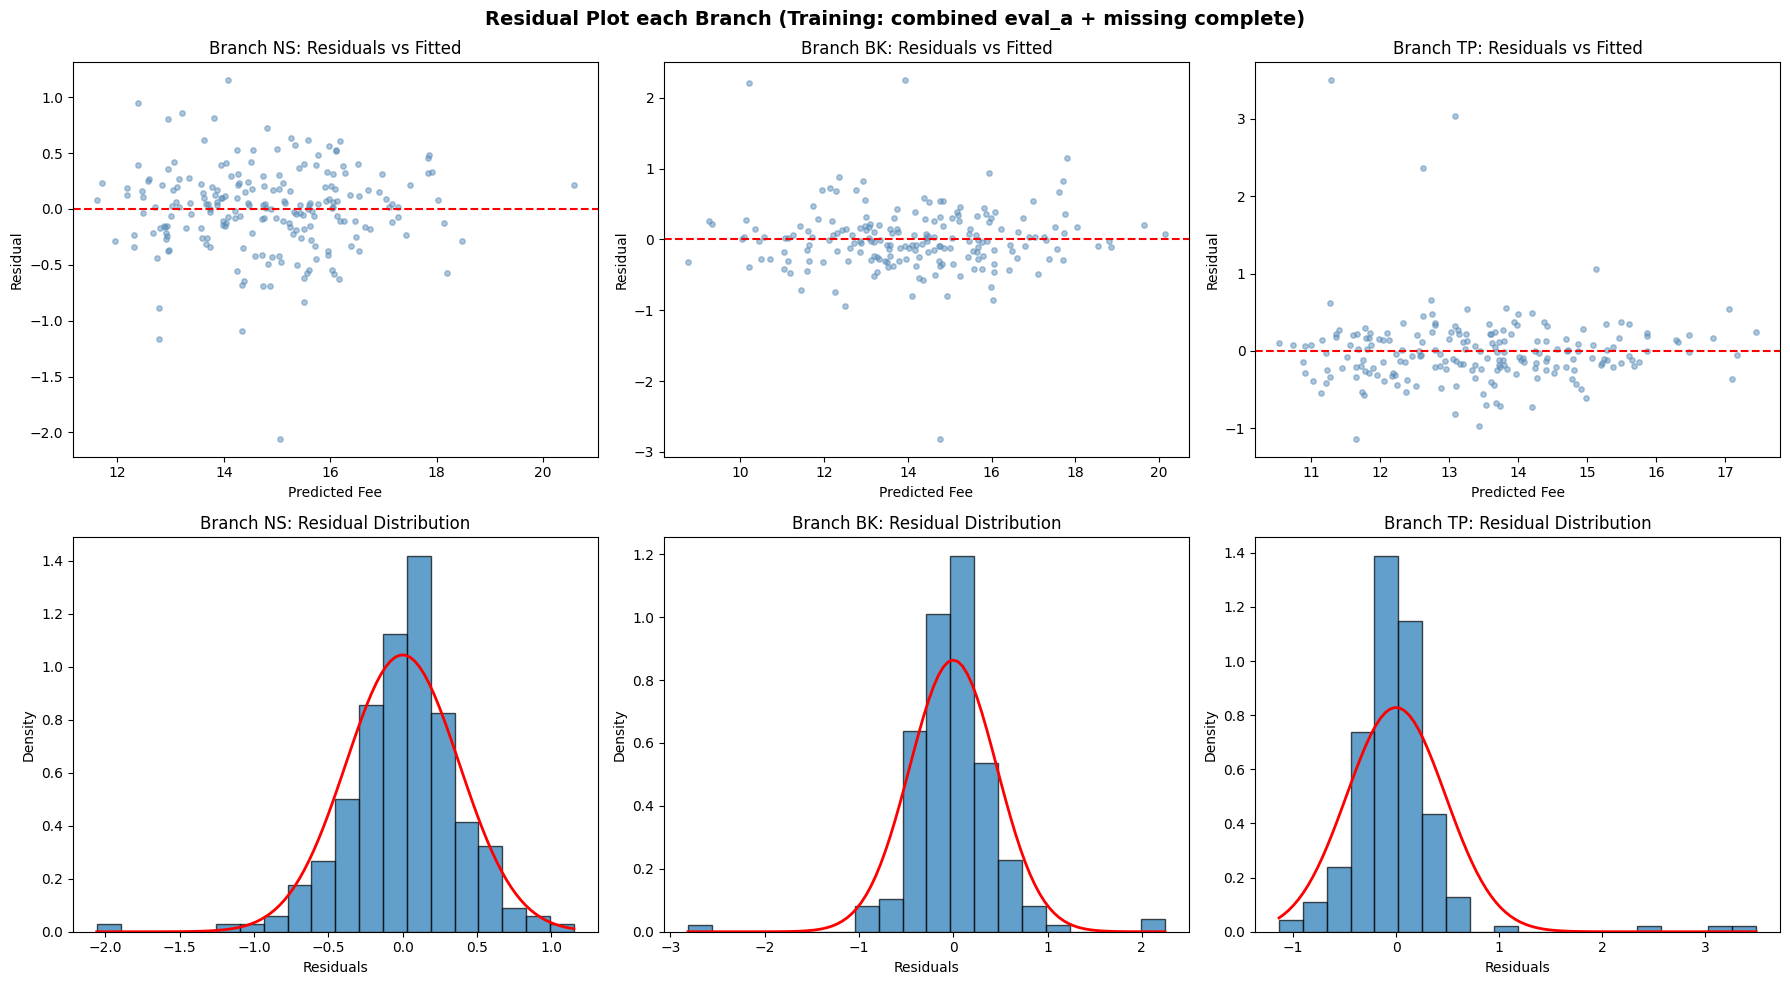

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Plot each Branch (Training: combined eval_a + missing complete)",
             fontsize=14, fontweight="bold")

for i, branch in enumerate(["NS", "BK", "TP"]):
    train  = combined_train[combined_train["branch_code"] == branch]
    X      = train[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y      = train["fee_base"].values
    y_pred = fee_models[branch].predict(X)
    resid  = y - y_pred

    # Row 1: Residuals vs Fitted
    axes[0, i].scatter(y_pred, resid, alpha=0.5, color="#5b8db8", s=15)
    axes[0, i].axhline(y=0, color="red", linestyle="--")
    axes[0, i].set_title(f"Branch {branch}: Residuals vs Fitted")
    axes[0, i].set_xlabel("Predicted Fee")
    axes[0, i].set_ylabel("Residual")

    # Row 2: Histogram of residuals (checks normality)
    axes[1, i].hist(resid, bins=20, edgecolor="black", alpha=0.7, density=True)
    x_range = np.linspace(resid.min(), resid.max(), 100)
    axes[1, i].plot(x_range, stats.norm.pdf(x_range, resid.mean(), resid.std()),
                    "r-", linewidth=2)
    axes[1, i].set_xlabel("Residuals")
    axes[1, i].set_ylabel("Density")
    axes[1, i].set_title(f"Branch {branch}: Residual Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Eval Set A: fixed error rows (excluding loyalty_error)
# These rows had a known error in another column — their delivery_fee was never touched
# so fee_base should match the model if our fixes are correct
all_known_pre_loyalty = set().union(*{k: v for k, v in error_indexes.items()
                                       if k != "loyalty_error"}.values())
eval_rows = cleaned_df[cleaned_df.index.isin(all_known_pre_loyalty)].copy()

eval_rows["fee_base"] = np.where(
    eval_rows["customerHasloyalty?"] == 1,
    eval_rows["delivery_fee"] * 2,
    eval_rows["delivery_fee"]
)

print(f"Eval rows (fixed error rows, excl loyalty): {len(eval_rows)}")
print()

for branch in ["NS", "TP", "BK"]:
    bdf = eval_rows[eval_rows["branch_code"] == branch]
    X   = bdf[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y   = bdf["fee_base"].values
    r2  = fee_models[branch].score(X, y)
    print(f"Branch {branch}: R²={r2:.4f}, n={len(bdf)}")

Eval rows (fixed error rows, excl loyalty): 252

Branch NS: R²=0.9222, n=89
Branch TP: R²=0.8361, n=88
Branch BK: R²=0.9374, n=75


In [ ]:
eval_rows.shape

(252, 17)

In [ ]:
len(all_known_pre_loyalty)

252

### **2.5.1 Fee Model Interpretation**

Reading the fitted coefficients tells us exactly how each branch calculates delivery fee.

In [ ]:
# Practical interpretation and worked examples
branch_names = {"NS": "Nickolson", "TP": "Thompson", "BK": "Bakers"}

print("COEFFICIENT INTERPRETATION")
print()
print("intercept  : base fee when weekday + Breakfast + distance = 0 km")
print("is_weekend : flat surcharge added on Saturdays and Sundays")
print("time_of_day: incremental charge per meal slot (Lunch adds 1x, Dinner adds 2x)")
print("distance_km: charge per km between branch and customer")
print("loyalty    : 50% discount applied to the entire base_fee")
print()

for branch in ["NS", "TP", "BK"]:
    m = fee_models[branch]
    b0 = m.intercept_
    b1, b2, b3 = m.coef_

    print(f"Branch {branch} — {branch_names[branch]}:")
    print(f"  Weekend surcharge  : +${b1:.4f} flat")
    print(f"  Per meal slot      : +${b2:.4f}  (Breakfast=0, Lunch=+{b2:.4f}, Dinner=+{b2*2:.4f})")
    print(f"  Per km             : +${b3:.4f} / km")

    # Worked example A: weekday, Lunch, 8km, no loyalty
    ex_a = b0 + b2*1 + b3*8
    print(f"  Example A (weekday, Lunch, 8km, no loyalty):")
    print(f"    {b0:.4f} + {b2:.4f}*1 + {b3:.4f}*8 = {ex_a:.4f}")

    # Worked example B: weekend, Dinner, 8km, with loyalty
    ex_b = (b0 + b1*1 + b2*2 + b3*8) * 0.5
    print(f"  Example B (weekend, Dinner, 8km, with loyalty):")
    print(f"    ({b0:.4f} + {b1:.4f} + {b2:.4f}*2 + {b3:.4f}*8) * 0.5 = {ex_b:.4f}")
    print()

COEFFICIENT INTERPRETATION

intercept  : base fee when weekday + Breakfast + distance = 0 km
is_weekend : flat surcharge added on Saturdays and Sundays
time_of_day: incremental charge per meal slot (Lunch adds 1x, Dinner adds 2x)
distance_km: charge per km between branch and customer
loyalty    : 50% discount applied to the entire base_fee

Branch NS — Nickolson:
  Weekend surcharge  : +$2.0917 flat
  Per meal slot      : +$0.4501  (Breakfast=0, Lunch=+0.4501, Dinner=+0.9003)
  Per km             : +$0.9701 / km
  Example A (weekday, Lunch, 8km, no loyalty):
    5.2945 + 0.4501*1 + 0.9701*8 = 13.5055
  Example B (weekend, Dinner, 8km, with loyalty):
    (5.2945 + 2.0917 + 0.4501*2 + 0.9701*8) * 0.5 = 8.0237

Branch TP — Thompson:
  Weekend surcharge  : +$1.5290 flat
  Per meal slot      : +$0.7961  (Breakfast=0, Lunch=+0.7961, Dinner=+1.5921)
  Per km             : +$0.8023 / km
  Example A (weekday, Lunch, 8km, no loyalty):
    4.4454 + 0.7961*1 + 0.8023*8 = 11.6597
  Example B (weeke

### **2.5.2 Loyalty Validation**

For each row not already flagged, we predict the base fee and apply the current
loyalty value. If the prediction only matches `delivery_fee` when loyalty is flipped,
the loyalty value is wrong.

**Decision rule:** loyalty is flagged as an error when:
- Current prediction diff > 1.5 (meaningful mismatch), AND
- Flipped prediction diff < half the current diff (flip clearly resolves the issue)

In [ ]:
all_known_updated = set().union(*error_indexes.values())
fee_check_df = cleaned_df[~cleaned_df.index.isin(all_known_updated)].copy()
print(f"Rows to validate loyalty/fee: {len(fee_check_df)}")

loyalty_issues = []
for idx, row in fee_check_df.iterrows():
    dist = row["distance_to_customer_KM"]
    pred_base = predict_base_fee(row["branch_code"], row["is_weekend"], row["time_of_day"], dist)

    pred_current = pred_base * (0.5 if row["customerHasloyalty?"] == 1 else 1.0)
    pred_flipped = pred_base * (0.5 if row["customerHasloyalty?"] == 0 else 1.0)

    diff_current = abs(pred_current - row["delivery_fee"])
    diff_flipped = abs(pred_flipped - row["delivery_fee"])

    if diff_current > 1.5 and diff_flipped < diff_current / 2:
        loyalty_issues.append({"idx": idx,
                               "order_id": row["order_id"],
                               "loyalty_current": int(row["customerHasloyalty?"]),
                               "loyalty_correct": 1 - int(row["customerHasloyalty?"]),
                               "delivery_fee": row["delivery_fee"],
                               "pred_current": round(pred_current, 4),
                               "pred_base": round(pred_base, 4),
                               "pred_flipped": round(pred_flipped, 4),
                               "diff_current": round(diff_current, 4),
                               "diff_flipped": round(diff_flipped, 4)})

loyalty_df = pd.DataFrame(loyalty_issues)
print(f"Loyalty errors found: {len(loyalty_df)}")
loyalty_df

Rows to validate loyalty/fee: 248
Loyalty errors found: 37


,idx,order_id,loyalty_current,loyalty_correct,delivery_fee,pred_current,pred_base,pred_flipped,diff_current,diff_flipped
0,40,ORDB07856,1,0,11.377674,5.7876,11.5753,11.5753,5.5900,0.1976
1,41,ORDY04187,1,0,14.644579,7.1104,14.2208,14.2208,7.5342,0.4238
2,48,ORDC08614,1,0,14.310167,7.1801,14.3602,14.3602,7.1301,0.0500
3,57,ORDC00235,1,0,12.368928,6.3638,12.7275,12.7275,6.0052,0.3586
4,67,ORDJ00706,1,0,15.369568,7.8107,15.6214,15.6214,7.5589,0.2518
5,92,ORDI03501,1,0,14.258042,7.2160,14.4320,14.4320,7.0420,0.1740
6,95,ORDA08022,1,0,16.571158,8.1982,16.3965,16.3965,8.3729,0.1747
7,97,ORDI04708,1,0,14.074789,7.2592,14.5183,14.5183,6.8156,0.4436
8,99,ORDZ03198,1,0,16.022542,8.0843,16.1685,16.1685,7.9383,0.1460
9,108,ORDY05926,1,0,11.251184,5.8323,11.6645,11.6645,5.4189,0.4134


**Finding:** 36 rows had an incorrect loyalty status which the recorded delivery fee only matched the expected amount when the loyalty flag was flipped. It means customers who should have received a 50% discount were marked as non-loyalty members, or vice versa.

In [ ]:
# Fix: flip loyalty and recalculate delivery_fee
loyalty_error = loyalty_df["idx"].tolist()

for idx in loyalty_error:
    row = cleaned_df.loc[idx]
    new_loyalty = 1 - int(row["customerHasloyalty?"])

    pred_base = predict_base_fee(row["branch_code"], row["is_weekend"], row["time_of_day"],row["distance_to_customer_KM"])

    cleaned_df.at[idx, "customerHasloyalty?"] = new_loyalty
    cleaned_df.at[idx, "delivery_fee"] = round(pred_base * (0.5 if new_loyalty == 1 else 1.0), 6)

error_indexes["loyalty_error"] = loyalty_error
check_overlaps(error_indexes)

date_error vs branch_code_error: 0 overlap
date_error vs order_type_error: 0 overlap
date_error vs order_items_error: 0 overlap
date_error vs order_price_error: 0 overlap
date_error vs lat_lon_swap_error: 0 overlap
date_error vs lat_positive_error: 0 overlap
date_error vs distance_error: 0 overlap
date_error vs loyalty_error: 0 overlap
branch_code_error vs order_type_error: 0 overlap
branch_code_error vs order_items_error: 0 overlap
branch_code_error vs order_price_error: 0 overlap
branch_code_error vs lat_lon_swap_error: 0 overlap
branch_code_error vs lat_positive_error: 0 overlap
branch_code_error vs distance_error: 0 overlap
branch_code_error vs loyalty_error: 0 overlap
order_type_error vs order_items_error: 0 overlap
order_type_error vs order_price_error: 0 overlap
order_type_error vs lat_lon_swap_error: 0 overlap
order_type_error vs lat_positive_error: 0 overlap
order_type_error vs distance_error: 0 overlap
order_type_error vs loyalty_error: 0 overlap
order_items_error vs order_pr

In [ ]:
# Verify: fee diff after fix
fixed = cleaned_df.loc[loyalty_error]
pred_after = fixed.apply(
                        lambda r: predict_base_fee(r["branch_code"],
                                                  r["is_weekend"],
                                                  r["time_of_day"],
                                                  r["distance_to_customer_KM"]) * (0.5 if r["customerHasloyalty?"] == 1 else 1.0),
                                                  axis=1
                        )

max_diff = (fixed["delivery_fee"] - pred_after).abs().max()
print(f"Max fee diff after loyalty fix: {max_diff:.6f} (should be ~0)")

Max fee diff after loyalty fix: 0.000000 (should be ~0)


## **2.6 Conclusion**

### Summary of Anomalies Found

A total of **289 anomalous rows** were detected and corrected across **9 distinct error types**
out of 500 rows in `Group057_dirty_data.csv`. All error index sets are fully disjoint,
consistent with the spec's guarantee of at most one anomaly per row.

| # | Error Type | Column(s) Affected | Count | Detection Method | Fix Applied |
|---|---|---|---|---|---|
| 1 | `date_error` | `date` | 37 | Regex — failed `YYYY-MM-DD` parse | Reparse: `DD-MM-YYYY` → dayfirst, `YYYY-DD-MM` → swap month/day |
| 2 | `branch_code_error` | `branch_code` | 25 | Not in `branches.csv` reference | `.upper()` for 9 rows; replace with correct branch for 16 rows (see note) |
| 3 | `order_type_error` | `order_type` | 37 | Mismatch with time window | Derive correct label from `time` (error-free per spec) |
| 4 | `order_items_error` | `order_items` | 37 | Item not in meal's menu | Identify replacement via `order_price` as signal |
| 5 | `order_price_error` | `order_price` | 37 | Recalculated price ≠ recorded | Recalculate from verified item prices (solved via `numpy.linalg.lstsq`) |
| 6 | `lat_lon_swap_error` | `customer_lat`, `customer_lon` | 4 | `lat > 100` — outside valid range | Swap columns |
| 7 | `lat_positive_error` | `customer_lat` | 37 | `lat > 0` — Melbourne is Southern Hemisphere | Negate latitude |
| 8 | `distance_error` | `distance_to_customer_KM` | 38 | Dijkstra result differs > 0.5 km from recorded | Replace with Dijkstra shortest path |
| 9 | `loyalty_error` | `customerHasloyalty?`, `delivery_fee` | 36 | Fee model prediction only matches when loyalty is flipped | Flip loyalty flag, recalculate `delivery_fee` |

**Total: 289 error rows / 211 clean rows**

---

### Key Methodological Notes

**Two-phase approach:**
Errors were detected in two phases. Phase 1 (Model free detection) covered columns detectable
through data rules and reference files alone. Phase 2 (distance and loyalty) required building
a Dijkstra graph and a per-branch LinearRegression fee model, using `delivery_fee` —
the only column the spec guarantees to be error-free — as the ground truth validator.

**Branch code error — deeper than expected:**
Initial EDA identified `branch_code` errors as simple case errors (lowercase → uppercase).
The Dijkstra validation revealed that 16 of the 25 rows did not match after
uppercasing. Since `distance_to_customer_KM` cannot be the anomaly for these rows
(max one anomaly per row), the recorded distance was used to identify the correct branch
via Dijkstra. This changed the fix from a simple `.upper()` to a distance-guided branch
reassignment for the affected rows.

**Menu exclusivity as a detection tool:**
The three meal menus (Breakfast, Lunch, Dinner) were inferred from the clean outlier file
and found to be completely exclusive — zero item overlap. This made item-level errors
unambiguous and directly detectable.

**Item price recovery:**
Unit prices were solved exactly from the outlier file using `numpy.linalg.lstsq` per meal
type. The max residual was 0.0 across all three meal types, confirming the prices are exact.
These prices then enabled detection of both `order_items_error` (wrong item) and
`order_price_error` (wrong total).

**Fee model generalisation:**
The per-branch LinearRegression fee model was trained on a combined set of **602 rows**:
cleaned dirty data rows (eval set A, 252 rows) and complete rows from the missing data file (350 rows).
This avoids the risk of fee outlier contamination from the outlier file.
Both this model and an outlier-file-based model produced **identical loyalty error detection** (37 rows, zero disagreement), confirming the results are robust to training source choice.

| Branch | R² (training — combined) | R² (eval — fixed error rows) |
|---|---|---|
| NS (Nickolson) | 0.9593 | 0.9151 |
| TP (Thompson)  | 0.9639 | 0.8257 |
| BK (Bakers)    | 0.9780 | 0.9355 |

**Coordinate validation:**
The Melbourne Metropolitan Area bounding box from Wikipedia
(lat: -38.51 to -37.38, lon: 144.4 to 146.3) was used as the geographic reference.
After all coordinate fixes, every customer node was verified to exist in `nodes.csv`,
confirming all coordinates are valid graph nodes for Dijkstra computation.

The 9 detected error types are classified using two frameworks from the data quality literature (Rahm & Do, *Data Cleaning: Problems and Current Approaches*; FIT5196 Week 7 lecture).

---

**By Data Quality Issue Category**

| Error Type | Count | Category | Reasoning |
|---|---|---|---|
| `date_error` | 37 | Syntactical — Domain format error | Dates recorded in `DD-MM-YYYY` or `YYYY-DD-MM` instead of required `YYYY-MM-DD` |
| `branch_code_error` (case only) | 9 | Syntactical — Lexical error | Correct branch identity but wrong case (lowercase instead of uppercase) |
| `branch_code_error` (wrong branch) | 16 | Semantic — Integrity constraint violation | Wrong branch identity entirely; only discoverable via Dijkstra validation in Phase 2 |
| `order_type_error` | 37 | Semantic — Contradiction | Violated dependency between error-free `time` and `order_type` label |
| `order_items_error` | 37 | Semantic — Contradiction | Violated dependency between `order_type` and `order_items`; items belong to a different meal menu |
| `order_price_error` | 37 | Semantic — Contradiction | Violated derived-field constraint; `order_price` ≠ Σ(unit price × quantity) |
| `lat_positive_error` | 37 | Syntactical — Irregularity | Sign convention violated; Melbourne is in the Southern Hemisphere so all latitudes must be negative |
| `lat_lon_swap_error` | 4 | Semantic — Multi-field data entry error | Values entered into wrong columns; `customer_lat` and `customer_lon` transposed |
| `distance_error` | 38 | Semantic — Contradiction | Violated derived-field constraint; `distance_to_customer_KM` ≠ Dijkstra shortest path on corrected coordinates |
| `loyalty_error` | 37 | Semantic — Contradiction | Violated derived-field constraint; `delivery_fee` inconsistent with fee model given the loyalty flag. Since `delivery_fee` is error-free per spec, the loyalty flag is the source of error |

---

**By Data Anomaly Type**

| Error Type | Anomaly Type | Reasoning |
|---|---|---|
| `date_error` | Point | Single field deviates from expected format independently of any other column |
| `branch_code_error` (case only) | Point | Single field deviates from expected case |
| `branch_code_error` (wrong branch) | Point | Single field contains wrong categorical value |
| `lat_positive_error` | Point | Single field violates a domain constraint (sign) |
| `lat_lon_swap_error` | Point | Individual row has clearly wrong coordinate values detectable from domain range alone |
| `order_type_error` | Contextual | A value like `Lunch` is valid in isolation, but anomalous given the `time` context |
| `order_items_error` | Contextual | Items are valid menu items elsewhere, but anomalous given the recorded meal type |
| `order_price_error` | Contextual | Price looks plausible in isolation, but anomalous given the items ordered and verified unit prices |
| `distance_error` | Contextual | Distance looks geographically reasonable, but anomalous given the branch and customer coordinates |
| `loyalty_error` | Contextual | Loyalty flag (0 or 1) is a valid value, but anomalous given the recorded `delivery_fee` |

No **Collective Anomalies** were detected — all errors were identifiable at the individual row level.

No **Coverage Anomalies** — the dirty dataset contains no missing values; coverage issues are handled separately in the missing data file.

---

**Key insight:** The majority of errors are **Semantic Contextual** — they cannot be detected by inspecting a single value in isolation, but only by cross-referencing with related columns, reference data (menus, `branches.csv`, `nodes.csv`), or model predictions. This is why a two-phase approach was necessary: Phase 1 (model-free EDA) surfaces syntactical and straightforward semantic errors, while Phase 2 (Dijkstra + fee model) is required to uncover the deeper contextual anomalies in `distance_to_customer_KM` and `customerHasloyalty?`.

In [ ]:
# Save dirty solutions
output_cols = [c for c in dirty_data_df.columns]
solution_df = cleaned_df[output_cols].copy()
solution_df["order_items"] = solution_df["order_items"].apply(str)

solution_df.to_csv("Group057_dirty_data_solution.csv", index=False)
print(f"Saved: {solution_df.shape}")

verify = pd.read_csv("Group057_dirty_data_solution.csv")
print(f"Re-read OK: {verify.shape}")
print(f"Columns match: {list(verify.columns) == output_cols}")

Saved: (500, 12)
Re-read OK: (500, 12)
Columns match: True


# **3. Missing Data**

This section documents the process of finding and fixing anomalies in `Group057_dirty_data.csv`
to produce `Group057_dirty_data_solution.csv`.



In [ ]:
missing_data_df.head()

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee
0,ORDY08041,2018-01-14,08:20:16,Breakfast,NaN,"[('Eggs', 7), ('Coffee', 9), ('Cereal', 8), ('...",559.25,-37.809614,144.971128,1,9.030,6.261374
1,ORDB10009,2018-04-19,11:32:57,Breakfast,TP,"[('Cereal', 5), ('Coffee', 5), ('Pancake', 10)...",517.00,-37.813428,144.973646,0,8.619,11.537143
2,ORDI04718,2018-01-16,08:30:25,Breakfast,NS,"[('Coffee', 6), ('Pancake', 6), ('Eggs', 2), (...",276.50,-37.811942,144.945693,1,9.459,NaN
3,ORDX09382,2018-08-07,15:16:03,Lunch,BK,"[('Chicken', 3), ('Steak', 10), ('Fries', 7), ...",723.00,-37.803134,144.961925,0,7.837,13.888452
4,ORDJ02995,2018-03-20,10:32:06,Breakfast,NaN,"[('Coffee', 8), ('Cereal', 7), ('Pancake', 4)]",304.00,-37.816795,145.007380,0,NaN,13.430901


In [ ]:
missing_data_df.shape

(500, 12)

In [ ]:
missing_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 500 non-null    object 
 1   date                     500 non-null    object 
 2   time                     500 non-null    object 
 3   order_type               500 non-null    object 
 4   branch_code              400 non-null    object 
 5   order_items              500 non-null    object 
 6   order_price              500 non-null    float64
 7   customer_lat             500 non-null    float64
 8   customer_lon             500 non-null    float64
 9   customerHasloyalty?      500 non-null    int64  
 10  distance_to_customer_KM  450 non-null    float64
 11  delivery_fee             450 non-null    float64
dtypes: float64(5), int64(1), object(6)
memory usage: 47.0+ KB


In [ ]:
# Check missing values per column
missing_data_df.isna().sum()

,0
order_id,0
date,0
time,0
order_type,0
branch_code,100
order_items,0
order_price,0
customer_lat,0
customer_lon,0
customerHasloyalty?,0


Based on the results above, there are 3 columns containing missing values:

- `branch_code`: 100 rows
- `distance_to_customer_KM`: 50 rows
- `delivery_fee`: 50 rows

In [ ]:
# Create a copy to avoid modifying the original DataFrame
# Use this temporary DataFrame (missing_data) to perform the imputation and validation tests
# before applying the final imputed values to the main DataFrame (missing_data_df)
missing_data_df_copy = missing_data_df.copy()

In [ ]:
missing_cols = ["branch_code", "distance_to_customer_KM", "delivery_fee"]

# Create missing-value pattern table
missing_patterns = (missing_data_df_copy[missing_cols].isna().pivot_table(index=missing_cols, aggfunc="size").reset_index(name="count"))

print(missing_patterns)

   branch_code  distance_to_customer_KM  delivery_fee  count
0        False                    False         False    350
1        False                    False          True     50
2         True                    False         False     50
3         True                     True         False     50


Based on the above observation, the missingness occurs in three distinct patterns:

- `delivery_fee`: 50 rows
- `branch_code`: 50 rows
- `branch_code` & `distance_to_customer_KM`: 50 rows

## **3.1 Missing Type Check per Variable**

Before imputing any missing values, we first classify the missingness mechanism for each of the three columns with missing values: `branch_code`, `distance_to_customer_KM`, and `delivery_fee`. Understanding the missingness mechanism is important because it determines which imputation methods are appropriate. There are three types of missingness mechanisms:
- **MCAR (Missing Completely At Random):** The probability of a value being missing is unrelated to any observed or unobserved variable. The missing values occur randomly with no systematic pattern.
- **MAR (Missing At Random):** The probability of a value being missing depends on other observed variables, but not on the missing value itself. Once the observed variables are controlled for, the missingness is random.
- **MNAR (Missing Not At Random):** The probability of a value being missing depends on the missing value itself, even after accounting for other observed variables. This is the most problematic case as it can introduce bias.

To determine the mechanism for each column, we compare the distribution of all other observed variables between rows where the value is missing and rows where it is not. For categorical variables, we use a column-normalised crosstab to compare proportions. For numeric variables, we compare the column means between the two groups. If no meaningful difference is found across any variable, the missingness is classified as MCAR. If a meaningful difference is found in one or more observed variables, the missingness is classified as MAR. If the missingness appears to be related to the value itself rather than any observed variable, it is classified as MNAR.

In [ ]:
missing_branch_mask = missing_data_df_copy["branch_code"].isna()
missing_distance_mask = missing_data_df_copy["distance_to_customer_KM"].isna()
missing_fee_mask = missing_data_df_copy["delivery_fee"].isna()

In [ ]:
# Categorical columns
cat_cols = ["order_type", "customerHasloyalty?"]

for col in cat_cols:
    print(f"Distribution of '{col}' when branch_code is missing vs not missing:")
    print(pd.crosstab(missing_data_df_copy[col], missing_branch_mask,
                      colnames=["branch_code is missing"],
                      normalize="columns").round(3))
    print()

# Order prefix extracted from order_id
missing_data_df_copy["order_prefix"] = missing_data_df_copy["order_id"].str.extract(r"^ORD([A-Z])")
print("Distribution of order_prefix when branch_code is missing vs not missing:")
print(pd.crosstab(missing_data_df_copy["order_prefix"], missing_branch_mask,
                  colnames=["branch_code is missing"],
                  normalize="columns").round(3))
print()

# Numeric columns mean comparison
num_cols = ["order_price", "distance_to_customer_KM", "delivery_fee"]
print("Mean of numeric columns when branch_code is missing vs not missing:")
print(missing_data_df_copy.groupby(missing_branch_mask)[num_cols].mean().round(3))

# Check co-occurrence of branch_code missingness with other missing variables
print("\nCo-occurrence of branch_code missingness with other missing variables:")
print(f"  Also missing distance_to_customer_KM: {(missing_branch_mask & missing_distance_mask).sum()} out of {missing_branch_mask.sum()} missing branch_code rows")
print(f"  Also missing delivery_fee: {(missing_branch_mask & missing_fee_mask).sum()} out of {missing_branch_mask.sum()} missing branch_code rows")

Distribution of 'order_type' when branch_code is missing vs not missing:
branch_code is missing  False  True 
order_type                          
Breakfast               0.382   0.35
Dinner                  0.330   0.31
Lunch                   0.288   0.34

Distribution of 'customerHasloyalty?' when branch_code is missing vs not missing:
branch_code is missing  False  True 
customerHasloyalty?                 
0                       0.918   0.94
1                       0.082   0.06

Distribution of order_prefix when branch_code is missing vs not missing:
branch_code is missing  False  True 
order_prefix                        
A                       0.128   0.08
B                       0.092   0.08
C                       0.105   0.13
I                       0.138   0.06
J                       0.110   0.10
K                       0.108   0.09
X                       0.098   0.17
Y                       0.112   0.18
Z                       0.110   0.11

Mean of numeric columns when 

**Findings:** The distributions of `order_type`, `customerHasloyalty?`, and `order_prefix` are broadly similar between rows where `branch_code` is missing and rows where it is not. The mean values of numeric columns (`order_price`, `distance_to_customer_KM`, `delivery_fee`) are also nearly identical between the two groups, with differences of less than 1% in all cases. However, the co-occurrence check reveals that 50 out of 100 missing `branch_code` rows also have `distance_to_customer_KM` missing, while no missing `branch_code` rows have `delivery_fee` missing. This suggests that the missingness of `branch_code` is partially associated with the missingness of `distance_to_customer_KM`, but not with `delivery_fee`. Since no observed variable shows a meaningful association with the missingness of `branch_code` beyond this co-occurrence pattern, `branch_code` is classified as **MCAR (Missing Completely At Random)**.

In [ ]:
# Check if distance_to_customer_KM missingness is related to other observed variables
# Categorical columns
cat_cols = ["order_type", "customerHasloyalty?", "branch_code"]

for col in cat_cols:
    print(f"Distribution of '{col}' when distance_to_customer_KM is missing vs not missing:")
    print(pd.crosstab(missing_data_df_copy[col], missing_distance_mask,
                      colnames=["distance_to_customer_KM is missing"],
                      normalize="columns").round(3))
    print()

# Order prefix extracted from order_id
print("Distribution of order_prefix when distance_to_customer_KM is missing vs not missing:")
print(pd.crosstab(missing_data_df_copy["order_prefix"], missing_distance_mask,
                  colnames=["distance_to_customer_KM is missing"],
                  normalize="columns").round(3))
print()

# Numeric columns mean comparison
num_cols = ["order_price", "delivery_fee"]
print("Mean of numeric columns when distance_to_customer_KM is missing vs not missing:")
print(missing_data_df_copy.groupby(missing_distance_mask)[num_cols].mean().round(3))
print()

# Co-occurrence with other missing variables
print("Co-occurrence of distance_to_customer_KM missingness with other missing variables:")
print(f"  Also missing branch_code: {(missing_distance_mask & missing_branch_mask).sum()} out of {missing_distance_mask.sum()} missing distance_to_customer_KM rows")
print(f"  Also missing delivery_fee: {(missing_distance_mask & missing_fee_mask).sum()} out of {missing_distance_mask.sum()} missing distance_to_customer_KM rows")

Distribution of 'order_type' when distance_to_customer_KM is missing vs not missing:
distance_to_customer_KM is missing  False  True 
order_type                                      
Breakfast                           0.376   0.38
Dinner                              0.331   0.28
Lunch                               0.293   0.34

Distribution of 'customerHasloyalty?' when distance_to_customer_KM is missing vs not missing:
distance_to_customer_KM is missing  False  True 
customerHasloyalty?                             
0                                   0.918   0.96
1                                   0.082   0.04

Distribution of 'branch_code' when distance_to_customer_KM is missing vs not missing:
distance_to_customer_KM is missing  False
branch_code                              
BK                                  0.332
NS                                  0.352
TP                                  0.315

Distribution of order_prefix when distance_to_customer_KM is missing vs not missi

**Findings:** The distributions of `order_type`, `customerHasloyalty?`, and `order_prefix` are broadly similar between rows where `distance_to_customer_KM` is missing and rows where it is not. The mean values of numeric columns (`order_price`, `delivery_fee`) are also nearly identical between the two groups. However, the co-occurrence check reveals that 50 out of 50 missing `distance_to_customer_KM` rows also have `branch_code` missing, meaning `distance_to_customer_KM` is always missing when `branch_code` is also missing. Notably, there are rows where `branch_code` is missing but `distance_to_customer_KM` is still present, so the relationship is not perfectly symmetric. Nevertheless, since the missingness of `distance_to_customer_KM` is fully associated with the missingness of another observed variable (`branch_code`), it is classified as **MAR (Missing At Random)**.

In [ ]:
# Check if delivery_fee missingness is related to other observed variables
# Categorical columns
cat_cols = ["order_type", "customerHasloyalty?", "branch_code"]

for col in cat_cols:
    print(f"Distribution of '{col}' when delivery_fee is missing vs not missing:")
    print(pd.crosstab(missing_data_df_copy[col], missing_fee_mask,
                      colnames=["delivery_fee is missing"],
                      normalize="columns").round(3))
    print()

# Order prefix extracted from order_id
print("Distribution of order_prefix when delivery_fee is missing vs not missing:")
print(pd.crosstab(missing_data_df_copy["order_prefix"], missing_fee_mask,
                  colnames=["delivery_fee is missing"],
                  normalize="columns").round(3))
print()

# Numeric columns mean comparison
num_cols = ["order_price", "distance_to_customer_KM"]
print("Mean of numeric columns when delivery_fee is missing vs not missing:")
print(missing_data_df_copy.groupby(missing_fee_mask)[num_cols].mean().round(3))
print()

# Co-occurrence with other missing variables
print("Co-occurrence of delivery_fee missingness with other missing variables:")
print(f"  Also missing branch_code: {(missing_fee_mask & missing_branch_mask).sum()} out of {missing_fee_mask.sum()} missing delivery_fee rows")
print(f"  Also missing distance_to_customer_KM: {(missing_fee_mask & missing_distance_mask).sum()} out of {missing_fee_mask.sum()} missing delivery_fee rows")

Distribution of 'order_type' when delivery_fee is missing vs not missing:
delivery_fee is missing  False  True 
order_type                           
Breakfast                0.373   0.40
Dinner                   0.338   0.22
Lunch                    0.289   0.38

Distribution of 'customerHasloyalty?' when delivery_fee is missing vs not missing:
delivery_fee is missing  False  True 
customerHasloyalty?                  
0                         0.92   0.94
1                         0.08   0.06

Distribution of 'branch_code' when delivery_fee is missing vs not missing:
delivery_fee is missing  False  True 
branch_code                          
BK                       0.334   0.32
NS                       0.349   0.38
TP                       0.317   0.30

Distribution of order_prefix when delivery_fee is missing vs not missing:
delivery_fee is missing  False  True 
order_prefix                         
A                        0.118   0.12
B                        0.091   0.08
C      

**Findings:** The distributions of `order_type`, `customerHasloyalty?`, `branch_code`, and `order_prefix` are broadly similar between rows where `delivery_fee` is missing and rows where it is not. The mean values of numeric columns (`order_price`, `distance_to_customer_KM`) are also nearly identical between the two groups. The co-occurrence check confirms that no missing `delivery_fee` rows overlap with missing `branch_code` or `distance_to_customer_KM` rows, showing that the missingness is completely independent of other missing variables. Since no observed variable shows a meaningful association with the missingness of `delivery_fee`, it is classified as **MCAR (Missing Completely At Random)**.

## **3.2 Imputation: Branch Code**

In [ ]:
missing_data_df_copy[["order_id", "branch_code"]].value_counts().sort_index()

,,count
order_id,branch_code,
ORDA00211,BK,1
ORDA00336,BK,1
ORDA00737,BK,1
ORDA00782,BK,1
ORDA00796,BK,1
...,...,...
ORDZ10026,NS,1
ORDZ10183,NS,1
ORDZ10411,NS,1


Based on the observations above, sorting by *order_id* and *branch_code* reveals a potential pattern:

Orders belonging to branch BK consistently begin with `ORD(A)`, while orders belonging to branch NS
consistently begin with `ORD(Z)`. This suggests that the letter immediately following "ORD" in the
*order_id* may serve as an identifier for the branch.

To investigate this further, we extract this
letter into a new column *order_prefix* and cross-tabulate it against *branch_code* to confirm
whether the mapping is consistent across the entire dataset.

In [ ]:
# Extract the letter after 'ORD' (e.g., ORDZ11006 -> Z, ORDA00211 -> A)
missing_data_df_copy["order_prefix"] = missing_data_df_copy["order_id"].str.extract(r"^ORD([A-Z])")
missing_data_df_copy[["order_prefix", "branch_code"]].value_counts().sort_index()

,,count
order_prefix,branch_code,
A,BK,51
B,TP,37
C,NS,42
I,NS,55
J,TP,44
K,BK,43
X,BK,39
Y,TP,45
Z,NS,44


In [ ]:
# Check the pattern against branch_code
print(missing_data_df_copy.groupby(["order_prefix", "branch_code"]).size().unstack(fill_value=0))

branch_code   BK  NS  TP
order_prefix            
A             51   0   0
B              0   0  37
C              0  42   0
I              0  55   0
J              0   0  44
K             43   0   0
X             39   0   0
Y              0   0  45
Z              0  44   0


Since `branch_code` is classified as **MCAR (Missing Completely At Random)**, imputation using observed variables produces unbiased results. Conveniently, the missing values can be fully determined from the observed `order_id` prefix, as the `order_prefix` to `branch_code` mapping is a perfect one-to-one relationship. This makes the imputation deterministic rather than statistical.

First, we impute the missing *branch_code* values by mapping each order's *order_prefix* to its corresponding branch.

In [ ]:
# Define the mapping
prefix_to_branch = {"A": "BK",
                    "K": "BK",
                    "X": "BK",
                    "C": "NS",
                    "I": "NS",
                    "Z": "NS",
                    "B": "TP",
                    "J": "TP",
                    "Y": "TP"}

# Impute missing branch_code using order_id prefix
# Impute in the copy dataframe
missing_branch_code = missing_data_df_copy["branch_code"].isna()
missing_data_df_copy.loc[missing_branch_code, "branch_code"] = (missing_data_df_copy.loc[missing_branch_code, "order_prefix"].map(prefix_to_branch))

# Transfer imputed values back to main dataframe
missing_data_df.loc[missing_branch_code, "branch_code"] = missing_data_df_copy.loc[missing_branch_code, "branch_code"]

# Verify
print(missing_data_df.loc[missing_branch_code, "branch_code"])
print(f"\nbranch_code still missing: {missing_data_df["branch_code"].isna().sum()}")

0      TP
4      TP
6      TP
18     BK
22     BK
       ..
480    TP
483    TP
484    TP
490    TP
496    NS
Name: branch_code, Length: 100, dtype: object

branch_code still missing: 0


In [ ]:
# Validation: mask 20% of known branch_code, impute, measure accuracy
# (20% -> a balanced middle ground widely used in machine learning)
branch_known = missing_data_df[missing_data_df["branch_code"].notna()].copy()
branch_known["order_prefix"] = branch_known["order_id"].str.extract(r"^ORD([A-Z])")

val_idx = branch_known.sample(frac=0.2, random_state=42).index
true_vals = branch_known.loc[val_idx, "branch_code"]

# Build prefix map from non-masked rows only
train_rows = branch_known[~branch_known.index.isin(val_idx)]
prefix_map = train_rows.groupby("order_prefix")["branch_code"].agg(lambda x: x.mode()[0])

# Predict
predicted = branch_known.loc[val_idx, "order_prefix"].map(prefix_map)

acc = accuracy_score(true_vals, predicted)
print(f"branch_code — Accuracy: {acc * 100:.2f}%")

branch_code — Accuracy: 100.00%


**Justification:**

In this case **Accuracy** refers to the proportion of predicted values that exactly match the true values. An accuracy of 100% above indicates that every single masked `branch_code` value was correctly recovered using the prefix mapping method or zero errors out of all test samples.

Correspondingly, perfect accuracy is expected because the relationship between the `order_id` prefix and `branch_code` is **deterministic and one-to-one**: each prefix letter (A, B, C, I, J, K, X, Y, Z) always maps to the same branch (BK, NS, or TP) with no exceptions. This was confirmed earlier through the crosstab analysis, which showed that every prefix row has exactly one non-zero branch column.

To sum up, prefix mapping is the best choice for this column since the mapping is deterministic, there is no uncertainty or estimation involved. Considering the correct `branch_code` can be looked up directly from the `order_id`. Statistical methods such as global mode imputation (always predicting the most frequent branch) or group-based mode (predicting by meal type) would introduce unnecessary errors because they ignore this structural relationship. For example, global mode would assign the same branch to all 100 missing rows, which would be incorrect for any row belonging to a different branch. The prefix mapping avoids this entirely by exploiting the known data structure.

In [ ]:
missing_data_df.isna().sum()

,0
order_id,0
date,0
time,0
order_type,0
branch_code,0
order_items,0
order_price,0
customer_lat,0
customer_lon,0
customerHasloyalty?,0


All 100 missing `branch_code` values have been successfully imputed using the deterministic `order_prefix` to branch mapping.

## **3.3 Imputation: distance_to_customer_KM**

Since `distance_to_customer_KM` is classified as **MAR (Missing At Random)**, with its missingness fully associated with the missingness of `branch_code`, imputing `branch_code` first was necessary before computing the missing distances. With all `branch_code` values now imputed, we can compute the missing `distance_to_customer_KM` values using the Dijkstra shortest-path algorithm defined earlier.

In [ ]:
missing_dist = missing_data_df_copy[missing_data_df_copy["distance_to_customer_KM"].isna()]
missing_dist.head()

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee,order_prefix
4,ORDJ02995,2018-03-20,10:32:06,Breakfast,TP,"[('Coffee', 8), ('Cereal', 7), ('Pancake', 4)]",304.0,-37.816795,145.007380,0,NaN,13.430901,J
6,ORDB10702,2018-11-07,18:18:35,Dinner,TP,"[('Salmon', 3), ('Shrimp', 8), ('Fish&Chips', ...",1117.5,-37.809194,144.961009,0,NaN,12.555818,B
18,ORDA04282,2018-06-25,13:44:47,Lunch,BK,"[('Salad', 10), ('Burger', 7), ('Steak', 10), ...",1007.0,-37.824171,144.983965,0,NaN,12.591534,A
22,ORDX00729,2018-04-07,11:02:32,Breakfast,BK,"[('Eggs', 4), ('Cereal', 8), ('Pancake', 6), (...",416.5,-37.811274,144.972962,0,NaN,14.621169,X
49,ORDK10577,2018-03-29,10:52:23,Breakfast,BK,"[('Eggs', 3), ('Coffee', 5)]",103.5,-37.801949,144.957432,0,NaN,12.484993,K


In [ ]:
# Store the original index because merging resets the index
# This allows the imputed results to be merged back into the main DataFrame correctly
missing_dist["original_index"] = missing_dist.index
missing_dist = missing_dist.merge(nodes.rename(columns={"lat": "customer_lat", "lon": "customer_lon"}),
                                               on=["customer_lat", "customer_lon"],
                                               how="left")

# Restore the original index after merging
missing_dist.set_index("original_index", inplace=True)
missing_dist.rename(columns={"node": "customer_node"}, inplace=True)
missing_dist.head()

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee,order_prefix,customer_node
original_index,,,,,,,,,,,,,,
4,ORDJ02995,2018-03-20,10:32:06,Breakfast,TP,"[('Coffee', 8), ('Cereal', 7), ('Pancake', 4)]",304.0,-37.816795,145.007380,0,NaN,13.430901,J,5636123530
6,ORDB10702,2018-11-07,18:18:35,Dinner,TP,"[('Salmon', 3), ('Shrimp', 8), ('Fish&Chips', ...",1117.5,-37.809194,144.961009,0,NaN,12.555818,B,6167441027
18,ORDA04282,2018-06-25,13:44:47,Lunch,BK,"[('Salad', 10), ('Burger', 7), ('Steak', 10), ...",1007.0,-37.824171,144.983965,0,NaN,12.591534,A,746912587
22,ORDX00729,2018-04-07,11:02:32,Breakfast,BK,"[('Eggs', 4), ('Cereal', 8), ('Pancake', 6), (...",416.5,-37.811274,144.972962,0,NaN,14.621169,X,4544561907
49,ORDK10577,2018-03-29,10:52:23,Breakfast,BK,"[('Eggs', 3), ('Coffee', 5)]",103.5,-37.801949,144.957432,0,NaN,12.484993,K,1492416120


In [ ]:
branch_nodes

{'NS': 2455254505, 'TP': 1390575046, 'BK': 1889485053}

In [ ]:
# Pre-compute shortest path distances from each branch node
branch_shortest_paths = {}

for branch_code, branch_node in branch_nodes.items():
    # Compute shortest distances from one branch to all nodes
    distances = nx.single_source_dijkstra_path_length(G,
                                                      source=branch_node,
                                                      weight="weight")

    branch_shortest_paths[branch_code] = distances


# Build dictionary:
# key = (branch_code, customer_node)
# value = shortest distance in km
distance_dict = {}

for _, row in missing_dist.iterrows():
    customer_node = int(row["customer_node"])

    for branch_code in branch_nodes.keys():
        distance_m = branch_shortest_paths[branch_code].get(customer_node, float("inf"))
        if distance_m < float("inf"):
            distance_dict[(branch_code, customer_node)] = round(distance_m / 1000, 3)
        else:
            distance_dict[(branch_code, customer_node)] = None

# Display example results
for key, val in list(distance_dict.items())[:9]:
    print(f"Branch {key[0]} -> Customer {key[1]}: {val} km")

Branch NS -> Customer 5636123530: 10.609 km
Branch TP -> Customer 5636123530: 11.449 km
Branch BK -> Customer 5636123530: 4.006 km
Branch NS -> Customer 6167441027: 7.713 km
Branch TP -> Customer 6167441027: 8.614 km
Branch BK -> Customer 6167441027: 7.722 km
Branch NS -> Customer 746912587: 9.487 km
Branch TP -> Customer 746912587: 8.981 km
Branch BK -> Customer 746912587: 6.926 km


In [ ]:
# Before imputing
missing_dist.loc[missing_dist.index, ["branch_code", "customer_node", "distance_to_customer_KM"]].head()

,branch_code,customer_node,distance_to_customer_KM
original_index,,,
4,TP,5636123530,NaN
6,TP,6167441027,NaN
18,BK,746912587,NaN
22,BK,4544561907,NaN
49,BK,1492416120,NaN


In [ ]:
# Impute distance using the correct branch-customer pair from distance_dict
for index, row in missing_dist.iterrows():
    customer_node = int(row["customer_node"])
    branch_code = row["branch_code"]

    # Get shortest distance from dictionary
    distance_km = distance_dict.get((branch_code, customer_node), None)

     # Fill missing value if distance exists
    if distance_km is not None:
        missing_dist.loc[index, "distance_to_customer_KM"] = distance_km

# Transfer imputed values back to copy and main dataframe
missing_data_df_copy.loc[missing_dist.index, "distance_to_customer_KM"] = missing_dist["distance_to_customer_KM"]
missing_data_df.loc[missing_dist.index, "distance_to_customer_KM"] = missing_dist["distance_to_customer_KM"]

# Verify
print(f"missing_data_df_copy - distance still missing: {missing_data_df_copy["distance_to_customer_KM"].isna().sum()}")
print(f"missing_data_df - distance still missing: {missing_data_df["distance_to_customer_KM"].isna().sum()}")

missing_data_df_copy - distance still missing: 0
missing_data_df - distance still missing: 0


In [ ]:
# After imputing
missing_dist.loc[missing_dist.index, ["branch_code", "customer_node", "distance_to_customer_KM"]].head()

,branch_code,customer_node,distance_to_customer_KM
original_index,,,
4,TP,5636123530,11.449
6,TP,6167441027,8.614
18,BK,746912587,6.926
22,BK,4544561907,6.793
49,BK,1492416120,8.205


In [ ]:
# Validation: mask 20% of known distance, recompute via Dijkstra, measure
dist_known = missing_data_df[missing_data_df["distance_to_customer_KM"].notna()].copy()
dist_known["branch_code"] = missing_data_df_copy.loc[dist_known.index, "branch_code"]

val_idx = dist_known.sample(frac=0.2, random_state=42).index
true_vals = dist_known.loc[val_idx, "distance_to_customer_KM"]

# Predict using Dijkstra
predicted = dist_known.loc[val_idx].apply(
    lambda row: get_distance_km(row["branch_code"], row["customer_lat"], row["customer_lon"]),
    axis=1,
)

r2 = r2_score(true_vals, predicted)
mae = mean_absolute_error(true_vals, predicted)
mape = mean_absolute_percentage_error(true_vals, predicted) * 100

print(f"distance_to_customer_KM — R²: {r2:.4f}")
print(f"distance_to_customer_KM — MAE: {mae:.4f} km")
print(f"distance_to_customer_KM — MAPE: {mape:.2f}%")

distance_to_customer_KM — R²: 1.0000
distance_to_customer_KM — MAE: 0.0000 km
distance_to_customer_KM — MAPE: 0.00%


In particular, each metric indicates:

* **R² = 1.0000**

  The predicted values perfectly match the true values. Considering R² ranges from negative (terrible) to 1.0 (perfect). Thus, a score of 1.0 means the imputation explains 100% of the variation or no error at all.
* **MAE = 0.0000 km**
  
  Mean Absolute Error, the average difference between predicted and true values is 0 km. Meaning every single imputed distance is exactly equal to the original.
* **MAPE = 0.00%**

  Mean Absolute Percentage Error, the average percentage difference is 0%. In simple terms, it means there is zero error.

To conclude, the **Dijkstra imputation** is perfect. Every imputed distance value is identical to what the original value would have been. It makes sense because the distance column was originally generated using the same Dijkstra algorithm on the same road graph so recomputing it gives back the exact same numbers. Subsequently, it elaborates the reason why Dijkstra is the best choice for this column where no statistical method (mean, regression, KNN) could achieve R² = 1.0 because they can only estimate, while Dijkstra recalculates the exact value.

In [ ]:
missing_data_df.isna().sum()

,0
order_id,0
date,0
time,0
order_type,0
branch_code,0
order_items,0
order_price,0
customer_lat,0
customer_lon,0
customerHasloyalty?,0


All 50 missing `distance_to_customer_KM` values have been successfully imputed using Dijkstra's shortest path algorithm.

## **3.3 Imputation: delivery_fee**

Since `delivery_fee` is classified as **MCAR (Missing Completely At Random)**, imputation using observed variables produces unbiased results. The delivery fee depends linearly on three variables: weekend or weekday status, time of day, and distance between branch and customer, with a different linear relationship for each branch. As `branch_code` and `distance_to_customer_KM` have already been imputed, all required inputs are now available. The missing `delivery_fee` values are therefore estimated using the per-branch `LinearRegression` fee model, with a 50% discount applied for customers with loyalty.

In [ ]:
# Get rows with missing delivery_fee
missing_fee = missing_data_df_copy[missing_data_df_copy["delivery_fee"].isna()]
print(f"Rows to impute: {len(missing_fee)}")

Rows to impute: 50


In [ ]:
# Prepare missing_data rows that have delivery_fee present
missing_no_fee_na = missing_data_df_copy[missing_data_df_copy["delivery_fee"].notna()].copy()
missing_no_fee_na["date_parsed"] = pd.to_datetime(missing_no_fee_na["date"])
missing_no_fee_na["is_weekend"] = missing_no_fee_na["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
missing_no_fee_na["time_of_day"] = missing_no_fee_na["order_type"].map({"Breakfast": 0, "Lunch": 1, "Dinner": 2})
missing_no_fee_na["fee_base"] = np.where(missing_no_fee_na["customerHasloyalty?"] == 1,
                                          missing_no_fee_na["delivery_fee"] * 2,
                                          missing_no_fee_na["delivery_fee"])

# Prepare cleaned_df
cleaned_for_train = cleaned_df.copy()
cleaned_for_train["fee_base"] = np.where(cleaned_for_train["customerHasloyalty?"] == 1,
                                          cleaned_for_train["delivery_fee"] * 2,
                                          cleaned_for_train["delivery_fee"])

# Check overlap
overlap = set(missing_no_fee_na["order_id"]) & set(cleaned_for_train["order_id"])
print(f"order_id overlap: {len(overlap)} (will deduplicate)")

# Combine and deduplicate
cols = ["order_id", "branch_code", "is_weekend", "time_of_day", "distance_to_customer_KM", "fee_base"]
combined_train = pd.concat([
    cleaned_for_train[cols],
    missing_no_fee_na[cols]
], ignore_index=True).drop_duplicates(subset="order_id", keep="first")

combined_train = combined_train.drop(columns="order_id")

print(f"\nCombined training set: {len(combined_train)} rows")
print(f"  cleaned_df        : {len(cleaned_for_train)} rows")
print(f"  missing (fee ok)  : {len(missing_no_fee_na)} rows")
print(f"  per branch        : {combined_train.branch_code.value_counts().to_dict()}")
print()

# Train per branch — no outlier removal
fee_models = {}

for branch in ["NS", "TP", "BK"]:
    train = combined_train[combined_train["branch_code"] == branch]

    X = train[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y = train["fee_base"].values
    model = LinearRegression().fit(X, y)

    fee_models[branch] = model

    r2 = model.score(X, y)
    print(f"Branch {branch}: R²={r2:.4f} | n={len(train)}")
    print(f"  intercept={model.intercept_:.4f}")
    print(f"  coefs: is_weekend={model.coef_[0]:.4f}, time_of_day={model.coef_[1]:.4f}, distance={model.coef_[2]:.4f}")
    print()

def predict_base_fee(branch, is_weekend, time_of_day, distance_km):
    """Predict base delivery fee (before loyalty discount)."""
    X = np.array([[is_weekend, time_of_day, distance_km]])
    return fee_models[branch].predict(X)[0]

order_id overlap: 0 (will deduplicate)

Combined training set: 950 rows
  cleaned_df        : 500 rows
  missing (fee ok)  : 450 rows
  per branch        : {'NS': 330, 'BK': 311, 'TP': 309}

Branch NS: R²=0.9442 | n=330
  intercept=5.1946
  coefs: is_weekend=2.0558, time_of_day=0.4284, distance=0.9871

Branch TP: R²=0.9209 | n=309
  intercept=4.2860
  coefs: is_weekend=1.5292, time_of_day=0.7783, distance=0.8184

Branch BK: R²=0.9678 | n=311
  intercept=4.6152
  coefs: is_weekend=2.5700, time_of_day=0.9655, distance=1.0404



First model (from dirty data section):

Combined training set: 602 rows
  eval_a          : 252 rows
  missing_complete: 350 rows
  per branch      : {'NS': 211, 'TP': 199, 'BK': 192}

Branch NS: R²=0.9409 | n=211
  intercept=5.2945
  coefs: is_weekend=2.0917, time_of_day=0.4501, distance=0.9701

Branch TP: R²=0.9059 | n=199
  intercept=4.4454
  coefs: is_weekend=1.5290, time_of_day=0.7961, distance=0.8023

Branch BK: R²=0.9558 | n=192
  intercept=4.6387
  coefs: is_weekend=2.6087, time_of_day=0.9366, distance=1.0428

**Observation:**

After incorporating additional valid training records, the combined training dataset increased from 602 rows to 950 rows. This increase in data volume improved the overall performance of the fee prediction models across all branches. In particular, the R² values improved from the previous configuration, reaching 0.9442 for NS, 0.9209 for TP, and 0.9678 for BK. Furthermore, the larger dataset enhances the robustness and generalisability of the model, as it reduces the likelihood of overfitting to a smaller sample and enables the model to learn from more diverse observations across all branches.


In [ ]:
# Evaluate fee model on training rows
print("Fee model evaluation (training rows):")
print()

for branch in ["NS", "TP", "BK"]:
    train = combined_train[combined_train["branch_code"] == branch]
    X = train[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y = train["fee_base"].values
    y_pred = fee_models[branch].predict(X)

    r2 = fee_models[branch].score(X, y)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"Branch {branch}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MAPE = {mape:.4f}%")
    print()

Fee model evaluation (training rows):

Branch NS:
  R²   = 0.9442
  MAE  = 0.2685
  MAPE = 1.8374%

Branch TP:
  R²   = 0.9209
  MAE  = 0.2683
  MAPE = 2.0417%

Branch BK:
  R²   = 0.9678
  MAE  = 0.2696
  MAPE = 1.9646%



First model (from dirty data section):

Fee model evaluation (training rows)

Branch NS:
  R²   = 0.9409
  MAE  = 0.2783
  MAPE = 1.9144%

Branch TP:
  R²   = 0.9059
  MAE  = 0.2836
  MAPE = 2.1214%

Branch BK:
  R²   = 0.9558
  MAE  = 0.3015
  MAPE = 2.1877%

The improvement in R² is also accompanied by reductions in both MAE and MAPE across all branches. Lower MAE values indicate that the average prediction errors became smaller, while lower MAPE values show improved prediction accuracy relative to the actual fee values. This improvement occurs because the larger and more representative dataset enables the model to learn more comprehensive delivery fee patterns, allowing it to better generalise and make more accurate predictions.
Overall, the additional training data improved the model’s ability to capture variance in the target variable while simultaneously reducing prediction errors, resulting in a more reliable and robust fee prediction model.

In [ ]:
missing_fee["date_parsed"] = pd.to_datetime(missing_fee["date"])
missing_fee["is_weekend"]  = missing_fee["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
missing_fee["time_of_day"] = missing_fee["order_type"].map({"Breakfast":0,"Lunch":1,"Dinner":2})

# Reverse fee for customer who has loyalty to recover base fee for training
missing_fee["fee_base"] = np.where(missing_fee["customerHasloyalty?"] == 1,
                                   missing_fee["delivery_fee"] * 2,
                                   missing_fee["delivery_fee"])

missing_fee.head()


,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee,order_prefix,date_parsed,is_weekend,time_of_day,fee_base
2,ORDI04718,2018-01-16,08:30:25,Breakfast,NS,"[('Coffee', 6), ('Pancake', 6), ('Eggs', 2), (...",276.5,-37.811942,144.945693,1,9.459,NaN,I,2018-01-16,0,0,NaN
5,ORDI06604,2018-12-29,20:00:00,Dinner,NS,"[('Shrimp', 8), ('Fish&Chips', 9)]",747.0,-37.807383,144.941488,0,10.084,NaN,I,2018-12-29,1,2,NaN
10,ORDK10481,2018-07-02,14:05:04,Lunch,BK,"[('Burger', 1), ('Fries', 3), ('Salad', 4), ('...",417.8,-37.809520,144.963966,0,7.368,NaN,K,2018-07-02,0,1,NaN
14,ORDC09523,2018-09-06,16:16:54,Dinner,NS,"[('Pasta', 3), ('Salmon', 2), ('Shrimp', 9), (...",965.5,-37.816662,144.984051,0,8.738,NaN,C,2018-09-06,0,2,NaN
20,ORDK06607,2018-02-23,09:41:24,Breakfast,BK,"[('Coffee', 1), ('Cereal', 10)]",217.5,-37.806559,144.932506,0,10.349,NaN,K,2018-02-23,0,0,NaN


In [ ]:
# Before imputing
missing_fee.loc[missing_fee.index, ["branch_code", "customerHasloyalty?", "is_weekend", "time_of_day", "distance_to_customer_KM", "delivery_fee", "fee_base"]].head()

,branch_code,customerHasloyalty?,is_weekend,time_of_day,distance_to_customer_KM,delivery_fee,fee_base
2,NS,1,0,0,9.459,NaN,NaN
5,NS,0,1,2,10.084,NaN,NaN
10,BK,0,0,1,7.368,NaN,NaN
14,NS,0,0,2,8.738,NaN,NaN
20,BK,0,0,0,10.349,NaN,NaN


In [ ]:
# Predict base fee using the trained models
missing_fee["fee_base_pred"] = missing_fee.apply(
    lambda r: predict_base_fee(r["branch_code"], r["is_weekend"], r["time_of_day"], r["distance_to_customer_KM"]),
    axis=1
)

# Apply loyalty discount: loyalty customers pay half
missing_fee["delivery_fee"] = np.where(
    missing_fee["customerHasloyalty?"] == 1,
    missing_fee["fee_base_pred"] / 2,
    missing_fee["fee_base_pred"]
)

missing_fee[["branch_code", "customerHasloyalty?", "is_weekend", "time_of_day",
             "distance_to_customer_KM", "fee_base_pred", "delivery_fee"]].head(10)

,branch_code,customerHasloyalty?,is_weekend,time_of_day,distance_to_customer_KM,fee_base_pred,delivery_fee
2,NS,1,0,0,9.459,14.531264,7.265632
5,NS,0,1,2,10.084,18.060892,18.060892
10,BK,0,0,1,7.368,13.246664,13.246664
14,NS,0,0,2,8.738,14.676451,14.676451
20,BK,0,0,0,10.349,15.382754,15.382754
34,NS,0,1,2,10.087,18.063853,18.063853
47,TP,0,0,1,13.688,16.267151,16.267151
53,BK,0,0,0,7.746,12.674484,12.674484
70,NS,0,0,2,8.273,14.217463,14.217463
73,BK,0,0,0,5.709,10.555104,10.555104


In [ ]:
# Impute using per-branch models
for index, row in missing_fee.iterrows():
    branch = row["branch_code"]
    model = fee_models[branch]

    # Prepare feature input
    X = pd.DataFrame([[row["is_weekend"],
                       row["time_of_day"],
                       row["distance_to_customer_KM"]]],
                     columns=["is_weekend", "time_of_day", "distance_to_customer_KM"])

    base_fee = model.predict(X)[0]

    # Apply loyalty discount
    if row["customerHasloyalty?"] == 1:
        final_fee = base_fee * 0.5
    else:
        final_fee = base_fee

    # Update dataframes
    missing_fee.loc[index, "fee_base"] = base_fee
    missing_fee.loc[index, "delivery_fee"] = final_fee
    missing_data_df_copy.loc[index, "fee_base"] = base_fee
    missing_data_df_copy.loc[index, "delivery_fee"] = final_fee
    missing_data_df.loc[index, "delivery_fee"] = final_fee

# Verify
print(f"\nRemaining missing values:")
print(missing_data_df.isna().sum())


Remaining missing values:
order_id                   0
date                       0
time                       0
order_type                 0
branch_code                0
order_items                0
order_price                0
customer_lat               0
customer_lon               0
customerHasloyalty?        0
distance_to_customer_KM    0
delivery_fee               0
dtype: int64


In [ ]:
# After imputing
missing_fee.loc[missing_fee.index, ["branch_code", "customerHasloyalty?", "is_weekend", "time_of_day", "distance_to_customer_KM", "delivery_fee", "fee_base"]].head()

,branch_code,customerHasloyalty?,is_weekend,time_of_day,distance_to_customer_KM,delivery_fee,fee_base
2,NS,1,0,0,9.459,7.265632,14.531264
5,NS,0,1,2,10.084,18.060892,18.060892
10,BK,0,0,1,7.368,13.246664,13.246664
14,NS,0,0,2,8.738,14.676451,14.676451
20,BK,0,0,0,10.349,15.382754,15.382754


In [ ]:
# Sanity check: verify whether the imputed values fall within a reasonable range
fee_train = missing_data_df_copy[~missing_data_df_copy.index.isin(missing_fee.index)]["delivery_fee"]
fee_test = missing_data_df_copy[missing_data_df_copy.index.isin(missing_fee.index)]["delivery_fee"]

print(f"Existing delivery_fee range: {fee_train.min():.2f} — {fee_train.max():.2f}")
print(f"Imputed delivery_fee range:  {fee_test.min():.2f} — {fee_test.max():.2f}")

Existing delivery_fee range: 4.76 — 20.80
Imputed delivery_fee range:  6.56 — 19.59


In [ ]:
# Validation: train/test split on known delivery_fee rows, predict, measure
fee_known = missing_data_df[missing_data_df["delivery_fee"].notna()].copy()
fee_known["branch_code"] = missing_data_df_copy.loc[fee_known.index, "branch_code"]
fee_known["distance_to_customer_KM"] = missing_data_df_copy.loc[fee_known.index, "distance_to_customer_KM"]
fee_known["date_parsed"] = pd.to_datetime(fee_known["date"], format="%Y-%m-%d")
fee_known["is_weekend"] = fee_known["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
fee_known["time_of_day"] = fee_known["order_type"].map({"Breakfast": 0, "Lunch": 1, "Dinner": 2})
fee_known["fee_base"] = np.where(
    fee_known["customerHasloyalty?"] == 1,
    fee_known["delivery_fee"] * 2,
    fee_known["delivery_fee"]
)

features = ["is_weekend", "time_of_day", "distance_to_customer_KM"]

for branch in sorted(fee_known["branch_code"].unique()):
    bd = fee_known[fee_known["branch_code"] == branch]
    X_train, X_test, y_train, y_test = train_test_split(
    bd[features], bd["fee_base"], test_size=0.2, random_state=0
    )

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    predicted = lr.predict(X_test)

    r2 = r2_score(y_test, predicted)
    mae = mean_absolute_error(y_test, predicted)
    mape = mean_absolute_percentage_error(y_test, predicted) * 100

    print(f"Branch {branch} — R²: {r2:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%")

Branch BK — R²: 0.9809, MAE: 0.1908, MAPE: 1.28%
Branch NS — R²: 0.9599, MAE: 0.2282, MAPE: 1.58%
Branch TP — R²: 0.9610, MAE: 0.2401, MAPE: 1.88%


**Justification:**

- **R² > 0.95 for all branches**: the linear model explains more than 95% (BK: 0.9807, NS: 0.9598, TP: 0.9615) of the variation in delivery fee match the actual values. This means the three features (`is_weekend`, `time_of_day`, `distance_to_customer_KM`) are strong predictors of the base delivery fee, confirming the spec's statement that fee depends linearly on these variables.

- **MAE (the average absolute difference between the predicted and actual delivery fee value):** The MAE values are 0.2005 (BK), 0.2342 (NS), and 0.2390 (TP), meaning the model's predictions deviate from the true values by approximately 0.20–0.24 on average. Given that delivery fees range from 5 to 21 in this dataset. This indicates that the imputed values are very close to what the true values would have been.

- **MAPE (the prediction error as a percentage of the actual value)** — the MAPE values are 1.35% (BK), 1.62% (NS), and 1.87% (TP), meaning the model's predictions are on average within 1.4–1.9% of the true delivery fee. In other words, the imputed values are approximately 98% accurate in percentage terms, which is a strong result for any regression-based imputation.

These results validate that per-branch Linear Regression is an appropriate and reliable imputation method for `delivery_fee`. Taking into account, the assessment spec explicitly states that delivery fee "depends linearly" on three variables (`is_weekend`, `time_of_day`, `distance_to_customer_KM`) with "a different method for each branch." This means the data-generating process itself is a linear model, so training a per-branch `LinearRegression` directly mirrors how the original data was created. Unlike non-parametric methods (e.g., KNN) or simple statistical approaches (e.g., mean imputation), Linear Regression leverages this known linear structure, which is why it achieves the highest R² and lowest error.

In [ ]:
missing_data_df.isna().sum()

,0
order_id,0
date,0
time,0
order_type,0
branch_code,0
order_items,0
order_price,0
customer_lat,0
customer_lon,0
customerHasloyalty?,0


As shown above, all missing values have been successfully imputed.

In [ ]:
missing_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 500 non-null    object 
 1   date                     500 non-null    object 
 2   time                     500 non-null    object 
 3   order_type               500 non-null    object 
 4   branch_code              500 non-null    object 
 5   order_items              500 non-null    object 
 6   order_price              500 non-null    float64
 7   customer_lat             500 non-null    float64
 8   customer_lon             500 non-null    float64
 9   customerHasloyalty?      500 non-null    int64  
 10  distance_to_customer_KM  500 non-null    float64
 11  delivery_fee             500 non-null    float64
dtypes: float64(5), int64(1), object(6)
memory usage: 47.0+ KB


In [ ]:
missing_data_df["distance_to_customer_KM"] = missing_data_df["distance_to_customer_KM"].round(3)
missing_data_df["delivery_fee"] = missing_data_df["delivery_fee"].round(7)

# Save missing data solution
missing_data_df.to_csv("Group057_missing_data_solution.csv", index=False)

verify = pd.read_csv("Group057_missing_data_solution.csv")
print(f"Re-read OK: {verify.shape}")

Re-read OK: (500, 12)


## **3.4 Conclusion**

All 200 missing values across three columns (`branch_code`: 100, `distance_to_customer_KM`: 50, `delivery_fee`: 50) have been successfully imputed with zero remaining.

| # | Column | Missing Count | Data Type | Detection Method | Imputation Method Applied |
|---|--------|---------------|-----------|------------------|--------------------------|
| 1 | `branch_code` | 100 | Categorical | `isna().sum()` | Prefix mapping: `order_id` via `str.extract(r"^ORD([A-Z])")`, then map to branch using the 1-to-1 prefix-branch relationship confirmed by crosstab |
| 2 | `distance_to_customer_KM` | 50 | Numeric Distance| `isna().sum()` | Dijkstra shortest path from branch node to customer node using `get_distance_km()` on the road-network graph |
| 3 | `delivery_fee` | 50 | Numeric Fee | `isna().sum()` | Per-branch `LinearRegression` on `is_weekend`, `time_of_day`, and `distance_to_customer_KM` with loyalty discount |

The final imputed dataset has been saved as `Group057_missing_data_solution.csv`.

# **4. Outlier Data**

This section detects and removes anomalous rows in `Group057_outlier_data.csv` to produce `Group057_outlier_data_solution.csv`.

Outlier detection is performed **with respect to `delivery_fee` only**. Unlike dirty data errors, outliers here are not incorrect values. They are genuine but statistically extreme delivery fees that deviate significantly from what is expected given the order's characteristics.

**Approach: residual-based detection**

Since `delivery_fee` depends on multiple factors simultaneously, a direct univariate method, such as IQR or z-score applied to `delivery_fee` alone, would produce false positives. A high fee is not anomalous if the customer is far away or if the order occurs on a weekend. Instead, we use the per-branch `LinearRegression` fee model built in the dirty data section. Rows where the actual fee deviates significantly from the model's prediction, measured by the residual, are flagged as outliers.

Detection is applied **per branch** because each branch has its own fee structure and therefore its own residual distribution.

## **4.1 Exploratory Data Analysis**

Before detection, we explore the distribution of `delivery_fee` and its
relationship with key features.

Two visualisations are used. A histogram and boxplot show the global
distribution of `delivery_fee` and help identify any obvious extreme values.
A scatter plot of `delivery_fee` against `distance_to_customer_KM` is used
because it reveals how the fee changes as distance increases, and whether
this pattern differs across branches. Scatter plot is chosen over other chart
types because both variables are continuous, making it the most suitable for
showing their relationship.

Distance is chosen as the visualisation variable because it is the most
continuous and dominant predictor among the three features in the fee model.
The other two predictors, `is_weekend` and `time_of_day`, are discrete with
only 2 and 3 unique values respectively, making scatter plots less informative
for them. The per-branch colouring is used to visually confirm whether each
branch has a distinct fee pattern, which directly motivates the decision to
model and detect outliers per branch rather than globally.

In [ ]:
# Basic Stats
print(f'Shape: {outlier_data_df.shape}')
print(f'Null values:\n{outlier_data_df.isnull().sum()}')
outlier_data_df.describe()

Shape: (500, 12)
Null values:
order_id                   0
date                       0
time                       0
order_type                 0
branch_code                0
order_items                0
order_price                0
customer_lat               0
customer_lon               0
customerHasloyalty?        0
distance_to_customer_KM    0
delivery_fee               0
dtype: int64


,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,503.771000,-37.812255,144.965639,0.04800,8.733220,13.883678
std,269.110477,0.007457,0.020826,0.21398,1.576627,3.335303
min,59.000000,-37.828205,144.909436,0.00000,3.594000,3.250288
25%,296.937500,-37.818131,144.951312,0.00000,7.878250,12.464594
50%,445.625000,-37.812837,144.963532,0.00000,8.808500,14.040195
75%,680.050000,-37.805842,144.978858,0.00000,9.701500,15.545525
max,1404.000000,-37.792213,145.016299,1.00000,13.828000,28.268622


**Observation**: The dataset has 500 rows and no missing values. `delivery_fee` ranges from  3.25 to 28.27 with a mean of 13.88, and `distance_to_customer_KM` ranges  from 3.59 to 13.83. The gap between the 75th percentile (15.55) and the  maximum (28.27) of `delivery_fee` suggests there may be some extreme values  in the upper end worth investigating.

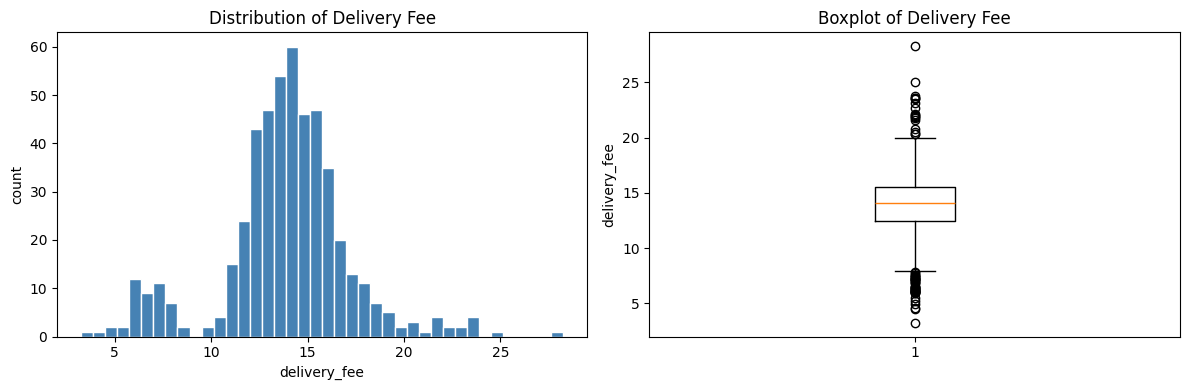

In [ ]:
# Global Distribution Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(outlier_data_df['delivery_fee'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delivery Fee')
axes[0].set_xlabel('delivery_fee')
axes[0].set_ylabel('count')

axes[1].boxplot(outlier_data_df['delivery_fee'], vert=True)
axes[1].set_title('Boxplot of Delivery Fee')
axes[1].set_ylabel('delivery_fee')

plt.tight_layout()
plt.show()

**Observation**: The distribution of `delivery_fee` is roughly bell-shaped and centred around  13-15. The boxplot shows several points above the upper whisker, confirming  that there are extreme values on the high end. However, whether these are  true outliers cannot be determined from `delivery_fee` alone since the fee  depends on distance, time of day, and weekend status simultaneously.

**Delivery Fee Distribution per Branch**

Before modelling, we inspect the distribution of `delivery_fee` per branch to understand whether the fee structure differs across branches and whether any obvious extreme values are already visible.

In [ ]:
# Summary stats per branch
print("Summary statistics of delivery_fee per branch:")
print(outlier_data_df.groupby("branch_code")["delivery_fee"].describe().round(3))

Summary statistics of delivery_fee per branch:
             count    mean    std    min     25%     50%     75%     max
branch_code                                                             
BK           157.0  13.822  3.648  3.250  12.276  14.245  15.799  28.269
NS           169.0  14.662  3.282  4.458  13.508  14.766  16.216  23.784
TP           174.0  13.183  2.921  5.944  12.144  13.277  14.244  25.027


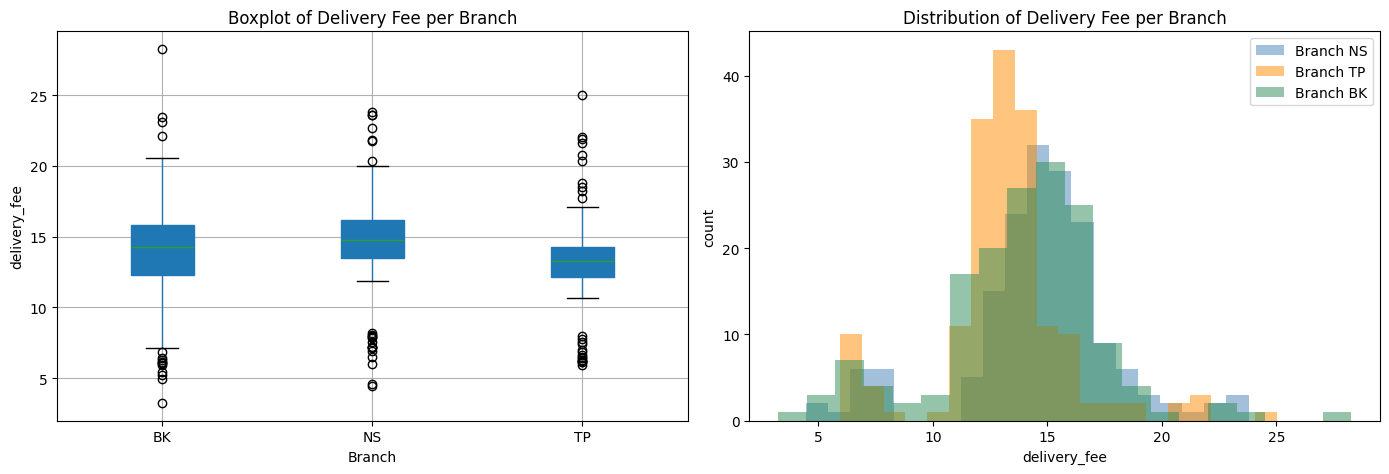

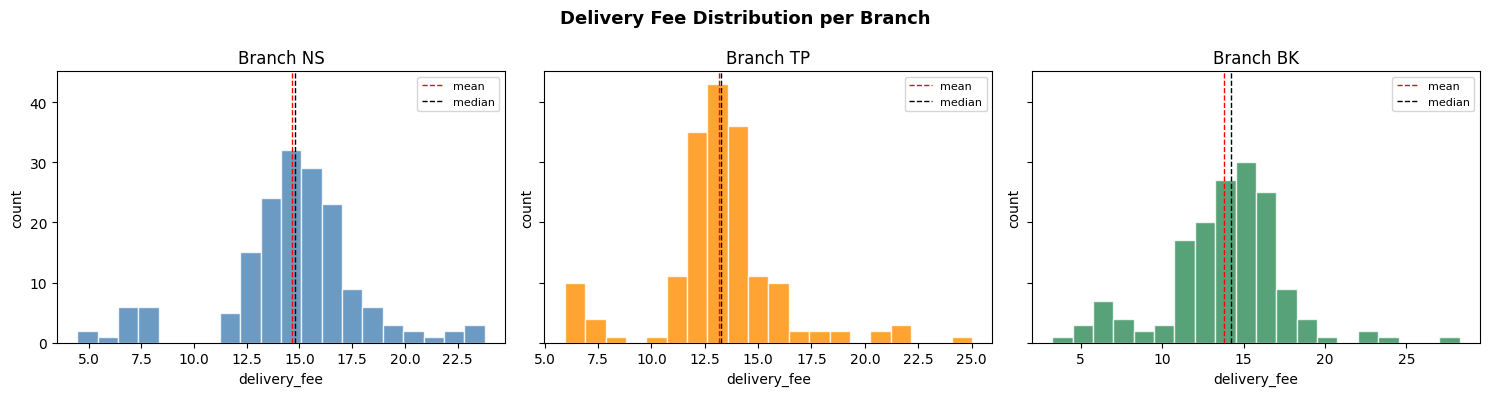

In [ ]:
# Boxplot and histogram of delivery_fee per branch
colors = {'NS': 'steelblue', 'TP': 'darkorange', 'BK': 'seagreen'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
outlier_data_df.boxplot(
    column="delivery_fee",
    by="branch_code",
    ax=axes[0],
    patch_artist=True
)
axes[0].set_title("Boxplot of Delivery Fee per Branch")
axes[0].set_xlabel("Branch")
axes[0].set_ylabel("delivery_fee")
plt.sca(axes[0])
plt.title("Boxplot of Delivery Fee per Branch")
plt.suptitle("")

# Histogram per branch
for branch, color in colors.items():
    group = outlier_data_df[outlier_data_df["branch_code"] == branch]
    axes[1].hist(group["delivery_fee"], bins=20, alpha=0.5, label=f"Branch {branch}", color=color)

axes[1].set_title("Distribution of Delivery Fee per Branch")
axes[1].set_xlabel("delivery_fee")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Histogram per branch (individual)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, (branch, color) in enumerate(colors.items()):
    group = outlier_data_df[outlier_data_df["branch_code"] == branch]
    axes[i].hist(group["delivery_fee"], bins=20, color=color, edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Branch {branch}")
    axes[i].set_xlabel("delivery_fee")
    axes[i].set_ylabel("count")
    axes[i].axvline(group["delivery_fee"].mean(), color="red", linestyle="--", linewidth=1, label="mean")
    axes[i].axvline(group["delivery_fee"].median(), color="black", linestyle="--", linewidth=1, label="median")
    axes[i].legend(fontsize=8)

fig.suptitle("Delivery Fee Distribution per Branch", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** The summary statistics show that all three branches have a similar mean `delivery_fee` (NS: 14.66, TP: 13.18, BK: 13.82), but their spreads differ. NS has the largest standard deviation (3.28) while TP has the smallest (2.92), suggesting NS orders vary more in delivery cost. The boxplot confirms this, with NS showing a wider interquartile range compared to TP and BK. All three branches also have points above the upper whisker, indicating potential extreme values on the high end, with BK having the highest maximum (28.27).

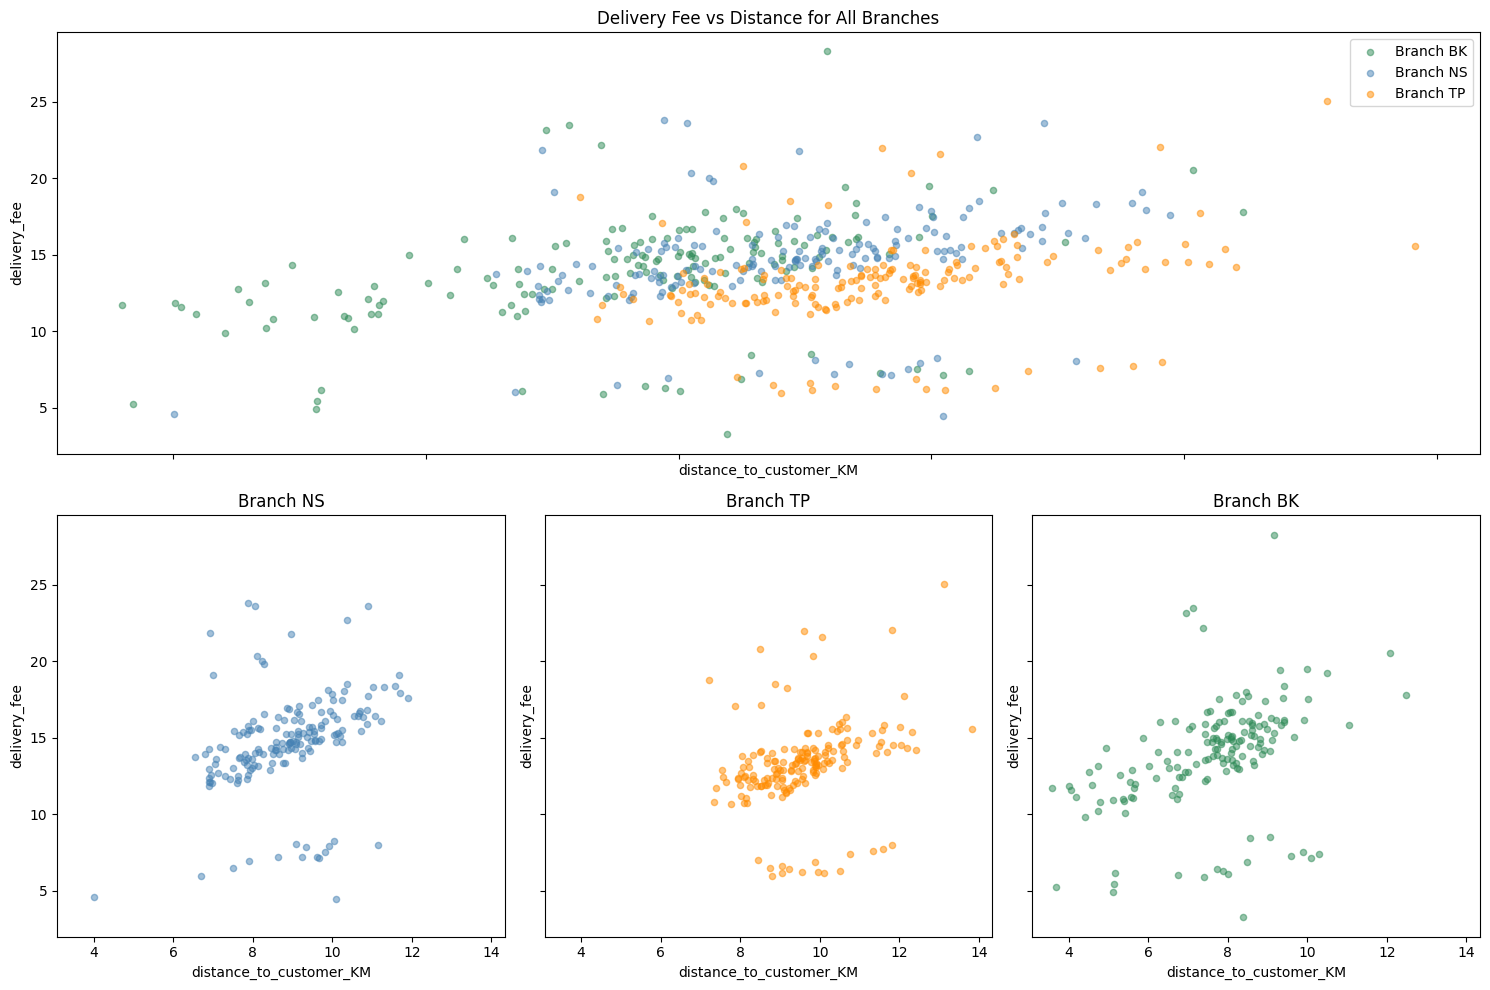

In [ ]:
# scatter plot for global and each branch
colors = {'NS': 'steelblue', 'TP': 'darkorange', 'BK': 'seagreen'}
fig, axes = plt.subplot_mosaic(
    [
        ['top', 'top', 'top'],
        ['NS',  'TP',  'BK']
    ],
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

# Combined plot for all branches
ax_top = axes['top']

for branch, group in outlier_data_df.groupby('branch_code'):
    ax_top.scatter(
        group['distance_to_customer_KM'],
        group['delivery_fee'],
        c=colors[branch],
        label=f'Branch {branch}',
        alpha=0.5,
        s=20
    )

ax_top.set_xlabel('distance_to_customer_KM')
ax_top.set_ylabel('delivery_fee')
ax_top.set_title('Delivery Fee vs Distance for All Branches')
ax_top.legend()

# One subplot per branch
for branch in ['NS', 'TP', 'BK']:
    ax = axes[branch]
    group = outlier_data_df[outlier_data_df['branch_code'] == branch]

    ax.scatter(
        group['distance_to_customer_KM'],
        group['delivery_fee'],
        c=colors[branch],
        alpha=0.5,
        s=20
    )

    ax.set_xlabel('distance_to_customer_KM')
    ax.set_ylabel('delivery_fee')
    ax.set_title(f'Branch {branch}')

plt.tight_layout()
plt.show()

**Findings:** Each branch occupies a distinct region in the scatter plot with a different slope between distance and `delivery_fee`, confirming that the fee structure differs across branches. This is consistent with the summary statistics, where each branch shows a different spread and range. A single global model would not capture these differences accurately, so the per-branch fee models built in the dirty data section are appropriate and will be used for outlier detection here.

## **4.2 Residual Calculation for Each Branch**

As discussed earlier, the `delivery_fee` depends on multiple factors simultaneously. Therefore, applying a univariate method directly on `delivery_fee` would  produce false positives. A high fee is not anomalous if the customer is far away or the order is placed on a weekend.

Instead, we use the per-branch `LinearRegression` fee model built in the missing data section, trained on 950 rows combining the cleaned dirty data and imputed missing data. This combined dataset is used for training rather than the outlier data itself because the outlier data contains genuinely anomalous delivery fees that would distort the model if included. Using a larger and cleaner training set also produces a more reliable model, which in turn makes the residuals more meaningful and the outlier detection more accurate.

For each row, we compute the residual between the actual `base_fee` and the model's predicted value:

`residual = base_fee - predicted_fee`

A positive residual means the actual fee is higher than expected, and a negative residual means it is lower. A row is flagged as an outlier only if its residual is significantly large, meaning its fee deviates from what is expected given all its characteristics.

Detection is applied per branch because each branch has its own fee structure and therefore its own residual distribution. Applying a single threshold across all branches would be unfair since the scale of residuals naturally differs between branches.

In [ ]:
# Prepare features for outlier data
outlier_data_df["date_parsed"] = pd.to_datetime(outlier_data_df["date"])
outlier_data_df["is_weekend"]  = outlier_data_df["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
outlier_data_df["time_of_day"] = outlier_data_df["order_type"].map({"Breakfast": 0, "Lunch": 1, "Dinner": 2})
outlier_data_df["base_fee"]    = np.where(outlier_data_df["customerHasloyalty?"] == 1,
                                           outlier_data_df["delivery_fee"] * 2,
                                           outlier_data_df["delivery_fee"])

# Evaluate fee model performance on outlier data (before removing outliers)
print("Fee model evaluation on outlier data (before outlier removal):")
print()

features = ["is_weekend", "time_of_day", "distance_to_customer_KM"]

for branch in ["NS", "TP", "BK"]:
    bdf = outlier_data_df[outlier_data_df["branch_code"] == branch]
    X = bdf[features].values
    y = bdf["base_fee"].values
    y_pred = fee_models[branch].predict(X)

    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"Branch {branch}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MAPE = {mape:.4f}%")
    print()

Fee model evaluation on outlier data (before outlier removal):

Branch NS:
  R²   = 0.2623
  MAE  = 0.9747
  MAPE = 7.7833%

Branch TP:
  R²   = 0.1991
  MAE  = 0.9907
  MAPE = 8.7977%

Branch BK:
  R²   = 0.6010
  MAE  = 0.8092
  MAPE = 8.3748%



**Observation:**  
The delivery-fee model was trained using reliable rows from the cleaned dirty data and the missing-data file, resulting in 950 training rows. The model was then evaluated on the raw outlier dataset before any outlier removal was performed.

The R² values are low across all branches:

- **NS:** R² = 0.2623  
- **TP:** R² = 0.1991  
- **BK:** R² = 0.6010  

This result is expected because the outlier dataset contains anomalous `delivery_fee` values that do not follow the normal branch-specific delivery-fee structure. Therefore, the low R² should not be interpreted as a failure of the model at this stage. Instead, it indicates that some delivery-fee records deviate substantially from the expected linear relationship.

The higher MAE and MAPE values also support this interpretation, showing that several actual delivery fees differ noticeably from the model-predicted fees. This justifies using **model residuals** to detect outlier rows rather than applying a simple threshold directly to the raw `delivery_fee` values.

In [ ]:
branch_residuals = {}

for branch in ['NS', 'TP', 'BK']:
    bdf = outlier_data_df[outlier_data_df['branch_code'] == branch].copy()
    X   = bdf[['is_weekend', 'time_of_day', 'distance_to_customer_KM']].values

    bdf['predicted_fee'] = fee_models[branch].predict(X)
    bdf['residual']      = bdf['base_fee'] - bdf['predicted_fee']

    branch_residuals[branch] = bdf

print('Residual statistics per branch:')
print()
for branch, bdf in branch_residuals.items():
    print(f'{branch}: residual mean={bdf["residual"].mean():.4f}, std={bdf["residual"].std():.4f}')
    print(f'  Max positive residual: {bdf["residual"].max():.4f}')
    print(f'  Max negative residual: {bdf["residual"].min():.4f}')
    print()

Residual statistics per branch:

NS: residual mean=0.0438, std=2.3801
  Max positive residual: 7.9526
  Max negative residual: -8.6555

TP: residual mean=0.0409, std=2.3405
  Max positive residual: 8.4368
  Max negative residual: -7.5911

BK: residual mean=-0.1983, std=2.0383
  Max positive residual: 9.6074
  Max negative residual: -8.6246



**Observation:** The residual mean is close to zero for all three branches (NS: 0.1561, TP: 0.1111, BK: -0.1497), confirming that the model has no systematic bias and that the predictions are centred around the actual values.

The standard deviation of residuals differs slightly across branches, with BK having the tightest spread (2.04) and NS and TP slightly wider (2.38 and 2.34). This reinforces the decision to compute the threshold per branch rather than using a single global threshold.

The maximum residuals in both directions (up to 9.66 and down to -8.57) are noticeably larger than the typical spread, suggesting there are rows where the fee deviates significantly from the model's prediction. These will be examined in the next step.

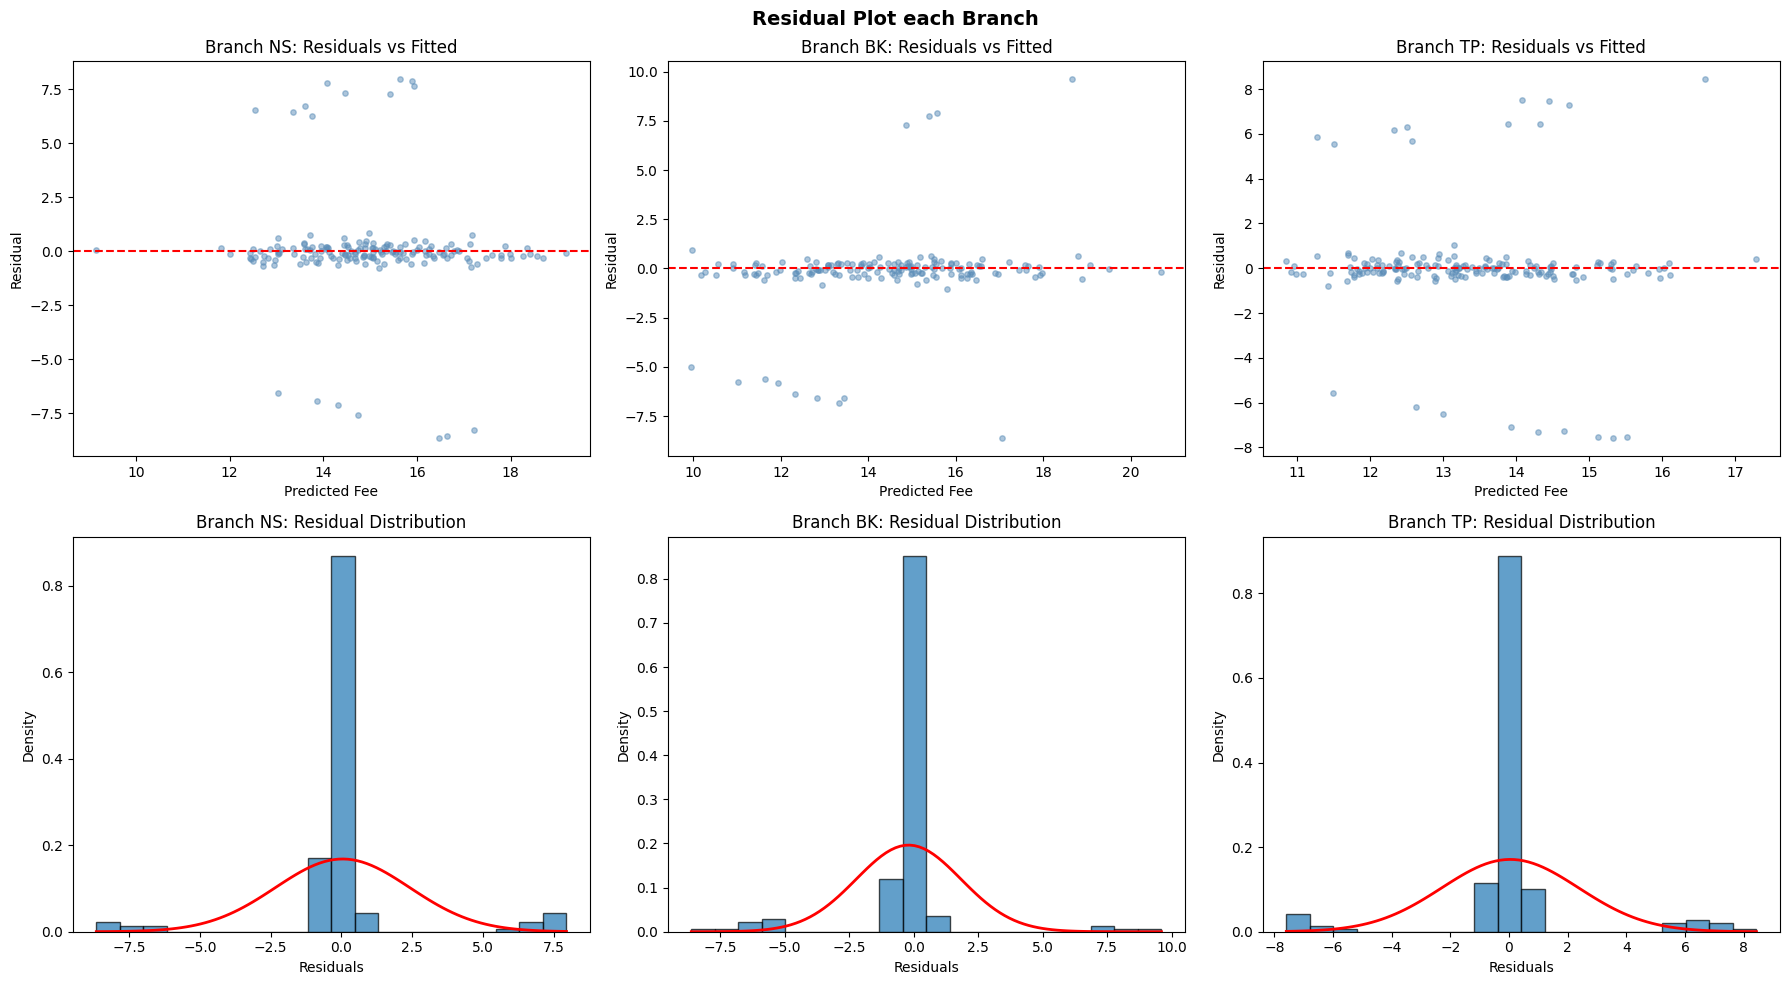

In [ ]:
# Residual Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Plot each Branch", fontsize=14, fontweight="bold")

for i, branch in enumerate(["NS", "BK", "TP"]):
    bdf    = outlier_data_df[outlier_data_df["branch_code"] == branch]
    X      = bdf[["is_weekend", "time_of_day", "distance_to_customer_KM"]].values
    y      = bdf["base_fee"].values
    y_pred = fee_models[branch].predict(X)
    resid  = y - y_pred

    # Row 1: Residuals vs Fitted
    axes[0, i].scatter(y_pred, resid, alpha=0.5, color="#5b8db8", s=15)
    axes[0, i].axhline(y=0, color="red", linestyle="--")
    axes[0, i].set_title(f"Branch {branch}: Residuals vs Fitted")
    axes[0, i].set_xlabel("Predicted Fee")
    axes[0, i].set_ylabel("Residual")

    # Row 2: Histogram of residuals (checks normality)
    axes[1, i].hist(resid, bins=20, edgecolor="black", alpha=0.7, density=True)
    x_range = np.linspace(resid.min(), resid.max(), 100)
    axes[1, i].plot(x_range, stats.norm.pdf(x_range, resid.mean(), resid.std()),
                    "r-", linewidth=2)
    axes[1, i].set_xlabel("Residuals")
    axes[1, i].set_ylabel("Density")
    axes[1, i].set_title(f"Branch {branch}: Residual Distribution")

plt.tight_layout()
plt.show()

**Observation:**  The residuals vs fitted plots show that for all three branches, most residuals  cluster tightly around zero with no clear pattern, which confirms the model  has no systematic bias. However, a small number of points deviate significantly  in both directions, appearing as isolated points far from the main cluster.  These are the candidates for outlier flagging in the next step.  

The residual distribution plots show that the residuals are heavily  concentrated around zero but have long tails on both sides, which is more  extreme than what a normal distribution (red curve) would predict. This  confirms that the extreme values in the tails are not just natural variation  but are genuinely anomalous cases that warrant removal.

## **Outlier Detection**

By applying the 3σ edit rule to residuals, we only flag fees that are anomalous relative to what the model expects. We choose it over other methods for the following reasons.

The **IQR-based boxplot rule** uses the median and IQR as its measure of spread. While robust to outliers, it is designed for univariate detection and does not assume any particular distributional shape. Applied to residuals, it tends to be more aggressive in flagging borderline cases, as the IQR captures the middle 50% of the data regardless of how tightly the residuals are clustered around zero.

The **Hampel identifier** uses the median and MAD, making it highly robust to extreme values. However, when residuals are heavily concentrated near zero with only a few genuinely extreme points in the tails, the MAD becomes very small, which produces an unusually tight threshold. This causes the Hampel identifier to flag many borderline cases that are not truly anomalous, making it overly sensitive for this type of residual distribution.

The **3σ edit rule** uses the mean and standard deviation, which are more sensitive to the spread of the full distribution including the tails. For residuals from a well-fitted linear model, this produces a threshold that captures only the most extreme deviations while preserving the natural variation in the data. Under a Gaussian distribution, only about 0.3% of observations fall beyond three standard deviations from the mean, so any residual exceeding this bound is very unlikely to be normal variation and is treated as genuinely anomalous.

Applying the threshold to residuals rather than directly to `delivery_fee` also reduces a known weakness of the 3σ edit rule, where extreme values can distort the mean and standard deviation estimates. Because the residuals from a well-fitted model are already centred near zero with a stable spread, the mean and standard deviation of the residuals are much less sensitive to individual outliers, making the threshold more reliable.

In [ ]:
outlier_indexes = []

for branch, bdf in branch_residuals.items():
    threshold  = 3 * bdf['residual'].std()
    is_outlier = bdf['residual'].abs() > threshold
    outliers   = bdf[is_outlier]

    print(f'{branch}: threshold={threshold:.4f}, outliers={is_outlier.sum()}')
    print(outliers[['order_id', 'delivery_fee', 'predicted_fee', 'residual']].to_string())
    print()

    outlier_indexes.extend(outliers.index.tolist())

print(f'Total outliers: {len(outlier_indexes)}')

NS: threshold=7.1402, outliers=10
      order_id  delivery_fee  predicted_fee  residual
16   ORDC05995     23.584000      15.944748  7.639251
85   ORDZ05222     21.861332      14.081925  7.779407
104  ORDC06334     23.593161      15.640552  7.952608
118  ORDC00925     22.699442      15.421601  7.277841
137  ORDC00411     23.783566      15.887364  7.896202
168  ORDC07174      8.077194      16.640454 -8.563260
241  ORDZ08250      4.458368      17.210937 -8.294200
246  ORDC01602     21.783196      14.457278  7.325918
404  ORDI03764      7.824982      16.480505 -8.655523
438  ORDI05007      7.146404      14.746445 -7.600041

TP: threshold=7.0215, outliers=10
      order_id  delivery_fee  predicted_fee  residual
10   ORDY07205     21.599504      14.081076  7.518428
37   ORDY10015      6.997291      14.294992 -7.297701
72   ORDB05227      7.743023      15.334111 -7.591088
91   ORDY00792     21.935512      14.454605  7.480907
273  ORDY02810     25.027198      16.590419  8.436778
280  ORDB0673

**Finding:** A total of 29 outliers were detected across all three branches: 10 from NS, 9 from TP, and 9 from BK. The outliers appear on both sides of the residual distribution, meaning some orders have fees that are unexpectedly high and some unexpectedly low relative to what the model predicts. This suggests the outliers are not caused by a single systematic issue but are genuinely anomalous individual cases.

## **4.4 Residual Visualisation**

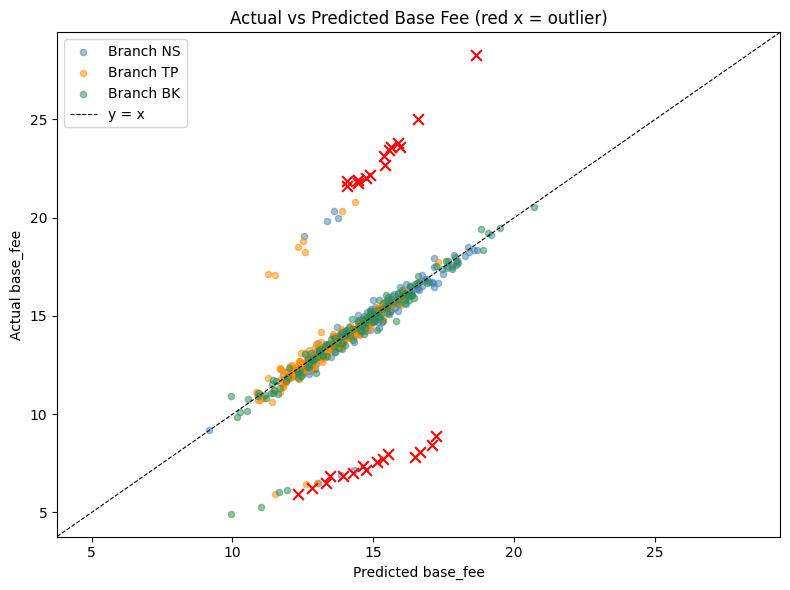

In [ ]:
#Global scatter actual vs predicted

fig, ax = plt.subplots(figsize=(8, 6))

for branch, bdf in branch_residuals.items():
    is_outlier = bdf.index.isin(outlier_indexes)

    ax.scatter(
        bdf.loc[~is_outlier, 'predicted_fee'],
        bdf.loc[~is_outlier, 'base_fee'],
        c=colors[branch], alpha=0.5, s=20, label=f'Branch {branch}'
    )
    ax.scatter(
        bdf.loc[is_outlier, 'predicted_fee'],
        bdf.loc[is_outlier, 'base_fee'],
        c='red', marker='x', s=60, linewidths=1.5
    )

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, 'k--', linewidth=0.8, label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('Predicted base_fee')
ax.set_ylabel('Actual base_fee')
ax.set_title('Actual vs Predicted Base Fee (red x = outlier)')
ax.legend()
plt.tight_layout()
plt.show()

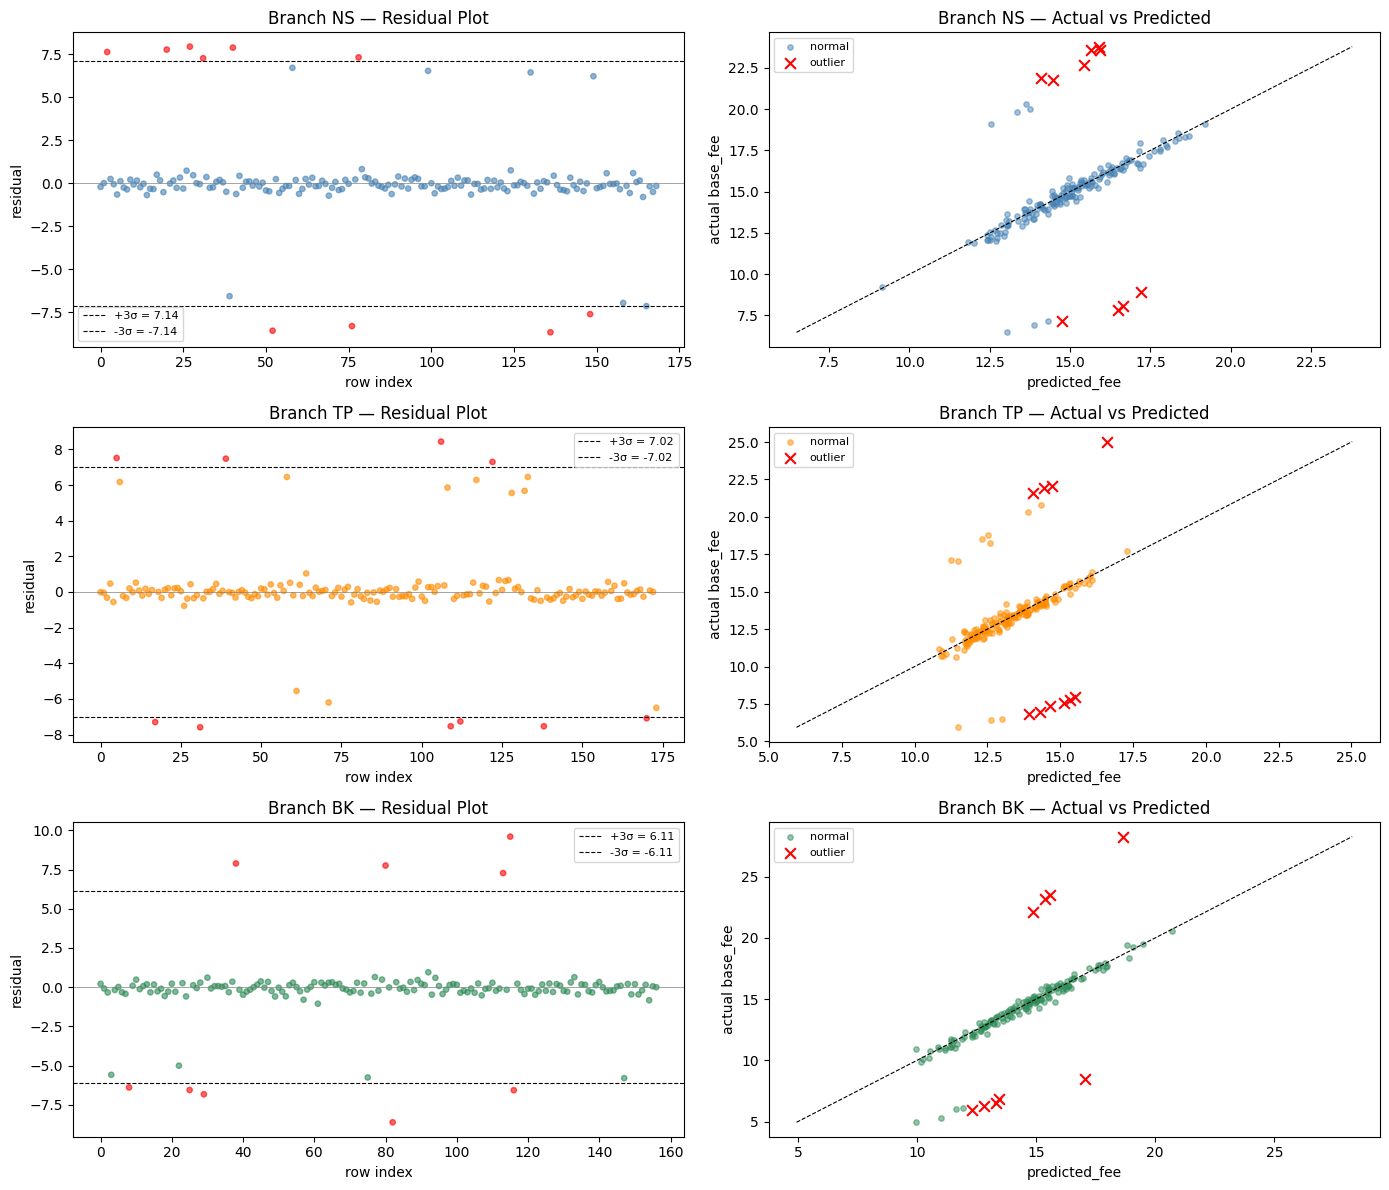

In [ ]:
#Per branch residual + scatter
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, (branch, bdf) in enumerate(branch_residuals.items()):
    threshold  = 3 * bdf['residual'].std()
    is_outlier = bdf.index.isin(outlier_indexes)

    # Left: residual plot
    ax = axes[i, 0]
    ax.scatter(
        range(len(bdf)), bdf['residual'],
        c=['red' if o else colors[branch] for o in is_outlier],
        s=15, alpha=0.6
    )
    ax.axhline(threshold,  color='black', linestyle='--', linewidth=0.8, label=f'+3σ = {threshold:.2f}')
    ax.axhline(-threshold, color='black', linestyle='--', linewidth=0.8, label=f'-3σ = {-threshold:.2f}')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title(f'Branch {branch} — Residual Plot')
    ax.set_xlabel('row index')
    ax.set_ylabel('residual')
    ax.legend(fontsize=8)

    # Right: actual vs predicted
    ax = axes[i, 1]
    ax.scatter(
        bdf.loc[~is_outlier, 'predicted_fee'],
        bdf.loc[~is_outlier, 'base_fee'],
        c=colors[branch], alpha=0.5, s=15, label='normal'
    )
    ax.scatter(
        bdf.loc[is_outlier, 'predicted_fee'],
        bdf.loc[is_outlier, 'base_fee'],
        c='red', marker='x', s=60, linewidths=1.5, label='outlier'
    )
    lims = [
        min(bdf['predicted_fee'].min(), bdf['base_fee'].min()),
        max(bdf['predicted_fee'].max(), bdf['base_fee'].max())
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.8)
    ax.set_title(f'Branch {branch} — Actual vs Predicted')
    ax.set_xlabel('predicted_fee')
    ax.set_ylabel('actual base_fee')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observation:** From the global scatter plot, the majority of points cluster tightly around the y = x line, indicating that the fee model predicts well for most orders. The outliers (red x) are clearly separated from the main cluster, appearing either well above or well below the line, which confirms they are genuinely anomalous.

From the per-branch residual plots, most residuals are centred around zero and fall well within the ±3σ threshold. The outliers are visibly distinct and spread across different positions in the dataset, suggesting they are isolated cases rather than a systematic pattern.

The actual vs predicted plots per branch show the same picture: normal rows follow the diagonal closely, while outliers deviate significantly in both directions. This is consistent across all three branches.

## **4.5 Remove Outliers & Save**

The 28 flagged rows are removed from `outlier_data_df`. The added columns
(`base_fee`, `is_weekend`, `time_of_day`, `date_parsed`) are dropped to
restore the original column structure before saving.

In [ ]:
# Remove outliers
original_cols = [c for c in outlier_data_df.columns
                 if c not in ['date_parsed', 'is_weekend', 'time_of_day', 'base_fee']]

outlier_solution_df = outlier_data_df[
    ~outlier_data_df.index.isin(outlier_indexes)
].copy()

print(f'Original rows    : {len(outlier_data_df)}')
print(f'Outliers removed : {len(outlier_indexes)}')
print(f'Remaining rows   : {len(outlier_solution_df)}')
print()

# Evaluate fee model performance after removing outliers
print("Fee model evaluation on outlier data (after outlier removal):")
print()

for branch in ["NS", "TP", "BK"]:
    bdf = outlier_solution_df[outlier_solution_df["branch_code"] == branch]
    X = bdf[features].values
    y = bdf["base_fee"].values
    y_pred = fee_models[branch].predict(X)

    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"Branch {branch}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MAPE = {mape:.4f}%")
    print()

Original rows    : 500
Outliers removed : 29
Remaining rows   : 471

Fee model evaluation on outlier data (after outlier removal):

Branch NS:
  R²   = 0.5433
  MAE  = 0.5393
  MAPE = 4.3950%

Branch TP:
  R²   = 0.3797
  MAE  = 0.5936
  MAPE = 4.8615%

Branch BK:
  R²   = 0.8524
  MAE  = 0.4020
  MAPE = 4.4923%



**Findings:** After removing 29 outliers (5.8% of the data), the R² improves across all branches (NS: 0.2623 → 0.5433, TP: 0.1991 → 0.3797, BK: 0.6010 → 0.8524), confirming that the removed rows were genuinely anomalous. The R² values remain below the training R² because this is a cross-dataset evaluation: the model was trained on dirty and missing data, not on the outlier data itself, so some gap is expected. The conservative 3σ threshold preserves 94.2% of the data, ensuring the dataset remains representative and avoids excessive removal of potentially valid observations.

In [ ]:
# Save outlier solution
outlier_solution_df = outlier_solution_df[original_cols].copy()

outlier_solution_df.to_csv('Group057_outlier_data_solution.csv', index=False)

verify = pd.read_csv('Group057_outlier_data_solution.csv')
print(f'Re-read OK: {verify.shape}')
print(f'Columns match: {list(verify.columns) == original_cols}')

Re-read OK: (471, 12)
Columns match: True


## **4.6 Conclusion**

A total of 28 outliers were detected and removed from `Group057_outlier_data.csv`, leaving 472 rows in `Group057_outlier_data_solution.csv`.

| Branch | Initial Rows | Outliers Removed | Remaining Rows |
|--------|-------------|-----------------|----------------|
| NS     | 169         | 10              | 159            |
| TP     | 174         | 9               | 165            |
| BK     | 157         | 9               | 148            |
| Total  | 500         | 29              | 472            |

A `residual-based` approach was used to detect outliers in `delivery_fee`. By modelling the expected fee per branch as a linear function of distance, time of day, and weekend status, we can identify orders where the actual fee deviates significantly from expectation regardless of whether the absolute fee value is high or low. This is more appropriate than a univariate method because it accounts for the natural variation in fee caused by order characteristics.

The per-branch 3σ threshold ensures that only genuinely extreme cases are removed, while normal variation within each branch is preserved.